# **PROBLEM STATEMENTS**



1) Analyse temporal crime trends from 2017–2022 to identify which crime categories increased or decreased year-over-year and quantify the change (absolute counts and per cent growth).
2) Identify geographical crime hotspots at the district and state level; compare crime rates across states and rank the highest-rate districts.
3) Compare the prevalence of crime types between urban and rural districts to determine whether certain crimes are concentrated in urban settings.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Hypothesis Analysis
# Insights of the graph
#

# **Importing the Dataset**

In [ ]:
df = pd.read_csv(r"/content/districtwise-ipc-crimes-2017-onwards.xlsx - districtwise-ipc-crimes-2017-on.csv")
df

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,clpbl_hmcrd_not_amt_murder,hit_and_run,...,ofnc_religion,cheating_impersonation,ofnc_mischief,arson,criminal_trespass,crlty_husbnd_relatives,crcl_false_fake_news_rumours,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,0,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,113,4,50,...,6,4,9,38,198,471,0,139,8,159
1,1,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,70,5,36,...,0,0,4,7,100,212,1,26,12,470
2,2,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,88,10,32,...,0,1,44,68,198,481,0,332,60,447
3,3,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,69,14,138,...,12,0,25,40,848,601,0,50,127,48
4,4,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,11,0,0,...,0,0,0,0,0,1,0,2,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5317,5317,2022,Jammu And Kashmir,1,Srinagar,13,Special Crime Wing Kashmir,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5318,5318,2022,Jammu And Kashmir,1,Srinagar,13,Anti Narcotic Task Force Kashmir,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5319,5319,2022,Jammu And Kashmir,1,Jammu,5,Economic Offences Wing (Eow) Jammu,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5320,5320,2022,Jammu And Kashmir,1,Srinagar,13,Economic Offences Wing (Eow) Kashmir,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
pd.set_option('display.max_columns', None) # displays all columns

display(df.head())

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,clpbl_hmcrd_not_amt_murder,hit_and_run,acdnt_other_than_hit_and_run_,deaths_negl_rel_rail_acdnt,deaths_due_med_negnc,deaths_neg_civic_bodies,deaths_other_negnc,dowry_deaths,abetment_of_suicide,atmpt_cmmt_murder,atmpt_cmmt_clpb_hmcrd,atmpt_cmmt_suicide,miscarr_infant_foetic_aband,vlntrly_caus_simple_hurt,vlntrly_caus_dangers_weapons,vlntrly_caus_pub_srvnt_duty,hrt_endgrng_lf_safety,other_simple_hurt,vlntrly_caus_grvus_hurt,grvus_hrt_dangerous_wepn,acid_attack,atmpt_acid_attack,grvus_hrt_pub_srvnt_duty,grvus_hrt_lf_safety,other_grievous_hurt,wrngful_rest_cnfm,assault_on_women,sex_hrrsmt_work_office_prms,sex_hrrsmt_pub_trnsprt_sys,sex_hrrsmt_shelter_homes,sex_hrrsmt_other_places,intnt_disrbe,voyeurism,stalking,missing_child_kidnpd,other_kidnp_abduc,kidnp_abdctn_begging,kidnp_abdctn_murder,kidnapping_for_ransom,kidnp_abdctn_marrg,proc_minor_girls,import_girls_frgn_cntry,other_kidnp_abduc_sec_365_369,human_trafficking,exp_traf_person,sell_minors_prost,buy_minors_prost,rape,atmpt_rape,unnatural_offences,ofnc_agnst_state_sedition,ofnc_agnst_state_other,ofnc_agnst_pub_trnqul,rioting_communal_religious,rioting_sectarian,rioting_industrial,rioting_political,rioting_caste_conflict,rioting_agrarian,rioting_students,rioting_vigilants,rioting_money_dispute,rioting_water_dispute,rioting_land_property_dispute,rioting_family_disputes,rioting_enmity_rivalry,riot_elec_pwr_disp,riot_andolan_morcha,riot_polc_prsnl_gvt_srvnt,other_rioting,prmt_enmty_grps,impt_asrtns_prjudc_intgrtn,affray,auto_motor_vehicle_theft,other_thefts,day_time_burglary,night_burglary,extortion_and_blackmailing,robbery,atmpt_dacoity_robbery,dacoity,dacoity_with_murder,mkng_prprtn_assmbly_cmmttng_dcty,criminal_misappropriation,criminal_breach_of_trust,dsh_hon_rec_deal_stl_prop,counterfeit_coin,cntrfte_govt_stamp,cntrft_seal_mark,cntrft_curr_bank_notes,bank_frauds,atm_fraud,credit_debit_card_fraud,other_frauds,cheating,forgery,ofnc_elections,disbnc_ordr_prmlgtd_pblc_srvnt,harboring_offender,sale_food_drugs,rash_driving_pub_way,csng_hrt_rsh_nglgnt_drvng_pblc_wy,grvus_hrt_rsh_nglgnt_drvng,obstruction_pub_way,sale_obscene_books_objects,obscene_acts_songs_public_places,ofnc_religion,cheating_impersonation,ofnc_mischief,arson,criminal_trespass,crlty_husbnd_relatives,crcl_false_fake_news_rumours,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,0,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,113,4,50,503,0,0,0,16,14,63,175,0,21,9,393,1610,11,10,0,7,59,0,0.0,0,0,0,107,196,0,5,58,50,43,5,60,8,17,3,0,4,32,16,0,6,3,0,0,0,43,11,0,0,0,35,4,0,0,3,3,0,0,0.0,0,0,15,19,17,0,5,5,3,5,0,79,176,279,55,219,27,23,1,5,0,0,0,28,0,0,0,0,6,20,26,3,200,137,4,3,16,0,6,1041,864,29,1,0,0,6,4,9,38,198,471,0,139,8,159
1,1,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,70,5,36,461,0,0,0,32,8,24,83,0,6,1,113,490,31,102,0,4,31,0,0.0,11,84,1,38,163,1,0,1,3,0,0,0,0,5,0,0,2,3,2,0,2,0,0,0,0,24,9,0,0,0,5,2,0,2,1,0,0,0,0.0,0,1,16,7,3,0,0,1,12,1,0,30,199,212,21,86,4,6,0,6,0,3,5,11,1,0,0,0,2,2,3,3,3,141,8,0,1,0,0,52,121,150,0,0,5,0,0,4,7,100,212,1,26,12,470
2,2,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,88,10,32,437,0,0,0,18,15,143,286,0,16,2,606,949,118,712,0,2,21,0,0.0,10,76,0,124,203,0,1,2,98,82,5,104,11,0,1,2,0,7,15,0,1,4,1,0,0,41,6,0,0,0,85,1,0,0,0,0,0,0,0.0,0,0,16,6,0,0,0,0,10,1,0,325,247,273,59,175,96,19,0,0,0,0,1,78,1,0,0,0,3,3,9,0,20,206,45,1,132,0,0,6636,130,30,10,0,4,0,1,44,68,198,481,0,332,60,447
3,3,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,69,14,138,503,0,0,0,23,10,18,74,0,109,0,112,809,62,6,0,0,20,3,0.0,14,7,0,333,223,0,0,0,136,63,23,62,0,25,0,1,3,4,6,0,5,0,0,0,0,108,12,1,0,0,4,0,0,0,3,0,0,0,0.0,0,0,2,0,3,0,0,0,0,6,0,4,347,613,64,308,33,16,3,2,0,0,1,91,0,0,0,0,4,0,0,0,0,296,33,0,50,0,0,1125,889,380,0,0,17,12,0,25,40,848,601,0,50,127,48
4,4,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,11,0,0,0,0,0,0,4,3,3,7,0,0,0,16,0,3,3,0,0,0,0,0.0,0,1,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Columns: 124 entries, id to other_ipc_crimes
dtypes: float64(2), int64(119), object(3)
memory usage: 5.0+ MB


In [ ]:
df = df.replace(0, np.nan)
print(df.isnull().sum().to_string())

id                                      1
year                                    0
state_name                              0
state_code                              0
district_name                           0
district_code                           0
registration_circles                    0
murder                                433
clpbl_hmcrd_not_amt_murder           1981
hit_and_run                          2186
acdnt_other_than_hit_and_run_        1668
deaths_negl_rel_rail_acdnt           5283
deaths_due_med_negnc                 4837
deaths_neg_civic_bodies              5214
deaths_other_negnc                   2905
dowry_deaths                         1825
abetment_of_suicide                  1668
atmpt_cmmt_murder                     560
atmpt_cmmt_clpb_hmcrd                3716
atmpt_cmmt_suicide                   3673
miscarr_infant_foetic_aband          3038
vlntrly_caus_simple_hurt             1660
vlntrly_caus_dangers_weapons         1630
vlntrly_caus_pub_srvnt_duty       

In [ ]:
null_counts = df.isnull().sum()
columns_with_more_than_5000_nulls = null_counts[null_counts > 5000]
num_columns = len(columns_with_more_than_5000_nulls)

print(f"Number of columns with more than 5000 null values: {num_columns}")
print("Columns:")
print(columns_with_more_than_5000_nulls.to_string())

Number of columns with more than 5000 null values: 25
Columns:
deaths_negl_rel_rail_acdnt    5283
deaths_neg_civic_bodies       5214
atmpt_acid_attack             5029
other_grievous_hurt           5101
sex_hrrsmt_shelter_homes      5043
kidnp_abdctn_begging          5185
import_girls_frgn_cntry       5307
exp_traf_person               5037
sell_minors_prost             5214
buy_minors_prost              5306
ofnc_agnst_state_sedition     5141
ofnc_agnst_state_other        5139
rioting_sectarian             5156
rioting_industrial            5092
rioting_vigilants             5312
riot_elec_pwr_disp            5227
riot_andolan_morcha           5019
impt_asrtns_prjudc_intgrtn    5127
dacoity_with_murder           5177
criminal_misappropriation     5066
counterfeit_coin              5276
cntrfte_govt_stamp            5310
cntrft_seal_mark              5292
harboring_offender            5122
sale_obscene_books_objects    5016


In [ ]:
df = df.drop(columns=columns_with_more_than_5000_nulls.index)

print("Columns with more than 5000 null values have been removed.")
print(f"New DataFrame shape: {df.shape}")

Columns with more than 5000 null values have been removed.
New DataFrame shape: (5322, 99)


In [ ]:
df['id'] = df['id'].astype(pd.Int64Dtype()) #changed the data type from float to int

In [ ]:
df['id'] = range(1, len(df) + 1)
df['id'] = df['id'].astype(pd.Int64Dtype()) #made the index to start from 1 for Id column

In [ ]:
df.head()

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,clpbl_hmcrd_not_amt_murder,hit_and_run,acdnt_other_than_hit_and_run_,deaths_due_med_negnc,deaths_other_negnc,dowry_deaths,abetment_of_suicide,atmpt_cmmt_murder,atmpt_cmmt_clpb_hmcrd,atmpt_cmmt_suicide,miscarr_infant_foetic_aband,vlntrly_caus_simple_hurt,vlntrly_caus_dangers_weapons,vlntrly_caus_pub_srvnt_duty,hrt_endgrng_lf_safety,other_simple_hurt,vlntrly_caus_grvus_hurt,grvus_hrt_dangerous_wepn,acid_attack,grvus_hrt_pub_srvnt_duty,grvus_hrt_lf_safety,wrngful_rest_cnfm,assault_on_women,sex_hrrsmt_work_office_prms,sex_hrrsmt_pub_trnsprt_sys,sex_hrrsmt_other_places,intnt_disrbe,voyeurism,stalking,missing_child_kidnpd,other_kidnp_abduc,kidnp_abdctn_murder,kidnapping_for_ransom,kidnp_abdctn_marrg,proc_minor_girls,other_kidnp_abduc_sec_365_369,human_trafficking,rape,atmpt_rape,unnatural_offences,ofnc_agnst_pub_trnqul,rioting_communal_religious,rioting_political,rioting_caste_conflict,rioting_agrarian,rioting_students,rioting_money_dispute,rioting_water_dispute,rioting_land_property_dispute,rioting_family_disputes,rioting_enmity_rivalry,riot_polc_prsnl_gvt_srvnt,other_rioting,prmt_enmty_grps,affray,auto_motor_vehicle_theft,other_thefts,day_time_burglary,night_burglary,extortion_and_blackmailing,robbery,atmpt_dacoity_robbery,dacoity,mkng_prprtn_assmbly_cmmttng_dcty,criminal_breach_of_trust,dsh_hon_rec_deal_stl_prop,cntrft_curr_bank_notes,bank_frauds,atm_fraud,credit_debit_card_fraud,other_frauds,cheating,forgery,ofnc_elections,disbnc_ordr_prmlgtd_pblc_srvnt,sale_food_drugs,rash_driving_pub_way,csng_hrt_rsh_nglgnt_drvng_pblc_wy,grvus_hrt_rsh_nglgnt_drvng,obstruction_pub_way,obscene_acts_songs_public_places,ofnc_religion,cheating_impersonation,ofnc_mischief,arson,criminal_trespass,crlty_husbnd_relatives,crcl_false_fake_news_rumours,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,1,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,113.0,4.0,50.0,503.0,NaN,16.0,14.0,63.0,175.0,NaN,21.0,9.0,393.0,1610.0,11.0,10.0,NaN,7.0,59.0,NaN,NaN,NaN,107.0,196.0,NaN,5.0,50.0,43.0,5.0,60.0,8.0,17.0,NaN,4.0,32.0,16.0,6.0,3.0,43.0,11.0,NaN,35.0,4.0,3.0,3.0,NaN,NaN,NaN,NaN,15.0,19.0,17.0,5.0,3.0,5.0,79.0,176.0,279.0,55.0,219.0,27.0,23.0,1.0,5.0,NaN,28.0,NaN,6.0,20.0,26.0,3.0,200.0,137.0,4.0,3.0,16.0,6.0,1041.0,864.0,29.0,1.0,NaN,6.0,4.0,9.0,38.0,198.0,471.0,NaN,139.0,8.0,159.0
1,2,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,70.0,5.0,36.0,461.0,NaN,32.0,8.0,24.0,83.0,NaN,6.0,1.0,113.0,490.0,31.0,102.0,NaN,4.0,31.0,NaN,11.0,84.0,38.0,163.0,1.0,NaN,3.0,NaN,NaN,NaN,NaN,5.0,NaN,2.0,3.0,2.0,2.0,NaN,24.0,9.0,NaN,5.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,16.0,7.0,3.0,1.0,12.0,1.0,30.0,199.0,212.0,21.0,86.0,4.0,6.0,NaN,6.0,3.0,11.0,1.0,2.0,2.0,3.0,3.0,3.0,141.0,8.0,NaN,1.0,NaN,52.0,121.0,150.0,NaN,5.0,NaN,NaN,4.0,7.0,100.0,212.0,1.0,26.0,12.0,470.0
2,3,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,88.0,10.0,32.0,437.0,NaN,18.0,15.0,143.0,286.0,NaN,16.0,2.0,606.0,949.0,118.0,712.0,NaN,2.0,21.0,NaN,10.0,76.0,124.0,203.0,NaN,1.0,98.0,82.0,5.0,104.0,11.0,NaN,2.0,NaN,7.0,15.0,1.0,4.0,41.0,6.0,NaN,85.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,16.0,6.0,NaN,NaN,10.0,1.0,325.0,247.0,273.0,59.0,175.0,96.0,19.0,NaN,NaN,NaN,78.0,1.0,3.0,3.0,9.0,NaN,20.0,206.0,45.0,1.0,132.0,NaN,6636.0,130.0,30.0,10.0,4.0,NaN,1.0,44.0,68.0,198.0,481.0,NaN,332.0,60.0,447.0
3,4,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,69.0,14.0,138.0,503.0,NaN,23.0,10.0,18.0,74.0,NaN,109.0,NaN,112.0,809.0,62.0,6.0,NaN,NaN,20.0,3.0,14.0,7.0,333.0,223.0,NaN,NaN,136.0,63.0,23.0,62.0,NaN,25.0,1.0,3.0,4.0,6.0,5.0,NaN,108.0,12.0,1.0,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,6.0,4.0,347.0,613.0,64.0,308.0,33.0,16.0,3.0,2.0,NaN,91.0,NaN,4.0,NaN,NaN,NaN,NaN,296.0,33.0,NaN,50.0,NaN,1125.0,889.0,380.0,NaN,17.0,12.0,NaN,25.0,40.0,848.0,601.0,NaN,50.0,127.0,48.0
4,5,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,11.0,NaN,NaN,NaN,NaN,4.0,3.0,3.0,7.0,NaN,NaN,NaN,16.0,NaN,3.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,N

In [ ]:
df.tail()

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,clpbl_hmcrd_not_amt_murder,hit_and_run,acdnt_other_than_hit_and_run_,deaths_due_med_negnc,deaths_other_negnc,dowry_deaths,abetment_of_suicide,atmpt_cmmt_murder,atmpt_cmmt_clpb_hmcrd,atmpt_cmmt_suicide,miscarr_infant_foetic_aband,vlntrly_caus_simple_hurt,vlntrly_caus_dangers_weapons,vlntrly_caus_pub_srvnt_duty,hrt_endgrng_lf_safety,other_simple_hurt,vlntrly_caus_grvus_hurt,grvus_hrt_dangerous_wepn,acid_attack,grvus_hrt_pub_srvnt_duty,grvus_hrt_lf_safety,wrngful_rest_cnfm,assault_on_women,sex_hrrsmt_work_office_prms,sex_hrrsmt_pub_trnsprt_sys,sex_hrrsmt_other_places,intnt_disrbe,voyeurism,stalking,missing_child_kidnpd,other_kidnp_abduc,kidnp_abdctn_murder,kidnapping_for_ransom,kidnp_abdctn_marrg,proc_minor_girls,other_kidnp_abduc_sec_365_369,human_trafficking,rape,atmpt_rape,unnatural_offences,ofnc_agnst_pub_trnqul,rioting_communal_religious,rioting_political,rioting_caste_conflict,rioting_agrarian,rioting_students,rioting_money_dispute,rioting_water_dispute,rioting_land_property_dispute,rioting_family_disputes,rioting_enmity_rivalry,riot_polc_prsnl_gvt_srvnt,other_rioting,prmt_enmty_grps,affray,auto_motor_vehicle_theft,other_thefts,day_time_burglary,night_burglary,extortion_and_blackmailing,robbery,atmpt_dacoity_robbery,dacoity,mkng_prprtn_assmbly_cmmttng_dcty,criminal_breach_of_trust,dsh_hon_rec_deal_stl_prop,cntrft_curr_bank_notes,bank_frauds,atm_fraud,credit_debit_card_fraud,other_frauds,cheating,forgery,ofnc_elections,disbnc_ordr_prmlgtd_pblc_srvnt,sale_food_drugs,rash_driving_pub_way,csng_hrt_rsh_nglgnt_drvng_pblc_wy,grvus_hrt_rsh_nglgnt_drvng,obstruction_pub_way,obscene_acts_songs_public_places,ofnc_religion,cheating_impersonation,ofnc_mischief,arson,criminal_trespass,crlty_husbnd_relatives,crcl_false_fake_news_rumours,criminal_intimidation,insult_modesty_women,other_ipc_crimes
5317,5318,2022,Jammu And Kashmir,1,Srinagar,13,Special Crime Wing Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5318,5319,2022,Jammu And Kashmir,1,Srinagar,13,Anti Narcotic Task Force Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5319,5320,2022,Jammu And Kashmir,1,Jammu,5,Economic Offences Wing (Eow) Jammu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,7.0,NaN,NaN,NaN,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5320,5321,2022,Jammu And Kashmir,1,Srinagar,13,Economic Offences Wing (Eow) Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5321,5322,2022,Jammu And Kashmir,1,Jammu,5,Cyber Crime Investigation Center For Excellenc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
df_rename_col = {
    "id": "Row_ID",
    "year": "Year",
    "state_name": "State_Name",
    "state_code": "State_Code",
    "district_name": "District_Name",
    "district_code": "District_Code",
    "registration_circles": "Police_Station_Circle",

    # Violent crimes
    "murder": "Murder",
    "clpbl_hmcrd_not_amt_murder": "Culpable_Homicide_Not_Amounting_to_Murder",
    "hit_and_run": "Hit_and_Run",
    "acdnt_other_than_hit_and_run_": "Accident_Other_than_Hit_and_Run",
    "deaths_due_med_negnc": "Deaths_Due_to_Medical_Negligence",
    "deaths_other_negnc": "Deaths_Due_to_Other_Negligence",
    "dowry_deaths": "Dowry_Deaths",
    "abetment_of_suicide": "Abetment_of_Suicide",
    "atmpt_cmmt_murder": "Attempt_to_Commit_Murder",
    "atmpt_cmmt_clpb_hmcrd": "Attempt_to_Commit_Culpable_Homicide",
    "atmpt_cmmt_suicide": "Attempt_to_Commit_Suicide",
    "miscarr_infant_foetic_aband": "Miscarriage_Infanticide_Foeticide_Abandonment",
    "vlntrly_caus_simple_hurt": "Voluntarily_Causing_Simple_Hurt",
    "vlntrly_caus_dangers_weapons": "Voluntarily_Causing_Hurt_by_Dangerous_Weapons",
    "vlntrly_caus_pub_srvnt_duty": "Voluntarily_Causing_Hurt_to_Public_Servant",
    "hrt_endgrng_lf_safety": "Hurt_Endangering_Life_or_Safety",
    "other_simple_hurt": "Other_Cases_of_Simple_Hurt",
    "vlntrly_caus_grvus_hurt": "Voluntarily_Causing_Grievous_Hurt",
    "grvus_hrt_dangerous_wepn": "Grievous_Hurt_by_Dangerous_Weapons",
    "acid_attack": "Acid_Attack",
    "grvus_hrt_pub_srvnt_duty": "Grievous_Hurt_to_Public_Servant",
    "grvus_hrt_lf_safety": "Grievous_Hurt_Endangering_Life",
    "wrngful_rest_cnfm": "Wrongful_Restraint_and_Confinement",

    # Women & kidnapping
    "assault_on_women": "Assault_on_Women",
    "sex_hrrsmt_work_office_prms": "Sexual_Harassment_at_Workplace",
    "sex_hrrsmt_pub_trnsprt_sys": "Sexual_Harassment_Public_Transport",
    "sex_hrrsmt_other_places": "Sexual_Harassment_Other_Places",
    "intnt_disrbe": "Intentional_Disruption",
    "voyeurism": "Voyeurism",
    "stalking": "Stalking",
    "missing_child_kidnpd": "Missing_Child_and_Kidnapping",
    "other_kidnp_abduc": "Other_Kidnapping_Abduction",
    "kidnp_abdctn_murder": "Kidnapping_Abduction_for_Murder",
    "kidnapping_for_ransom": "Kidnapping_for_Ransom",
    "kidnp_abdctn_marrg": "Kidnapping_Abduction_for_Marriage",
    "proc_minor_girls": "Procuration_of_Minor_Girls",
    "other_kidnp_abduc_sec_365_369": "Kidnapping_Abduction_Sec_365_369",
    "human_trafficking": "Human_Trafficking",
    "rape": "Rape",
    "atmpt_rape": "Attempt_to_Rape",
    "unnatural_offences": "Unnatural_Sexual_Offences",
    "crlty_husbnd_relatives": "Cruelty_by_Husband_and_Relatives",
    "insult_modesty_women": "Insult_to_Modesty_of_Women",
    "other_ipc_crimes": "Other_IPC_Crimes",

    # Public order
    "ofnc_agnst_pub_trnqul": "Offences_Against_Public_Tranquility",
    "rioting_communal_religious": "Rioting_Communal_Religious",
    "rioting_political": "Rioting_Political",
    "rioting_caste_conflict": "Rioting_Caste_Conflict",
    "rioting_agrarian": "Rioting_Agrarian",
    "rioting_students": "Rioting_by_Students",
    "rioting_money_dispute": "Rioting_Money_Dispute",
    "rioting_water_dispute": "Rioting_Water_Dispute",
    "rioting_land_property_dispute": "Rioting_Land_Property_Dispute",
    "rioting_family_disputes": "Rioting_Family_Disputes",
    "rioting_enmity_rivalry": "Rioting_Enmity_Rivalry",
    "riot_polc_prsnl_gvt_srvnt": "Rioting_Police_Personnel_Government_Servants",
    "other_rioting": "Other_Rioting",
    "prmt_enmty_grps": "Promoting_Enmity_Between_Groups",
    "affray": "Affray",

    # Property crimes
    "auto_motor_vehicle_theft": "Auto_Motor_Vehicle_Theft",
    "other_thefts": "Other_Thefts",
    "day_time_burglary": "Day_Time_Burglary",
    "night_burglary": "Night_Burglary",
    "extortion_and_blackmailing": "Extortion_and_Blackmailing",
    "robbery": "Robbery",
    "atmpt_dacoity_robbery": "Attempt_to_Dacoity_or_Robbery",
    "dacoity": "Dacoity",
    "mkng_prprtn_assmbly_cmmttng_dcty": "Making_Preparation_for_Dacoity",
    "criminal_breach_of_trust": "Criminal_Breach_of_Trust",
    "dsh_hon_rec_deal_stl_prop": "Dishonest_Receiver_Dealing_Stolen_Property",
    "cntrft_curr_bank_notes": "Counterfeit_Currency_Bank_Notes",
    "bank_frauds": "Bank_Frauds",
    "atm_fraud": "ATM_Fraud",
    "credit_debit_card_fraud": "Credit_Debit_Card_Fraud",
    "other_frauds": "Other_Frauds",
    "cheating": "Cheating",
    "forgery": "Forgery",
    "ofnc_elections": "Offences_Relating_to_Elections",
    "disbnc_ordr_prmlgtd_pblc_srvnt": "Disobedience_to_Order_of_Public_Servant",
    "sale_food_drugs": "Sale_of_Adulterated_Food_or_Drugs",
    "rash_driving_pub_way": "Rash_or_Negligent_Driving_on_Public_Way",
    "csng_hrt_rsh_nglgnt_drvng_pblc_wy": "Causing_Hurt_by_Rash_Negligent_Driving",
    "grvus_hrt_rsh_nglgnt_drvng": "Grievous_Hurt_by_Rash_Negligent_Driving",
    "obstruction_pub_way": "Obstruction_on_Public_Way",
    "obscene_acts_songs_public_places": "Obscene_Acts_and_Songs_in_Public_Places",
    "ofnc_religion": "Offences_Relating_to_Religion",
    "cheating_impersonation": "Cheating_by_Personation",
    "ofnc_mischief": "Mischief",
    "arson": "Arson",
    "criminal_trespass": "Criminal_Trespass",
    "crlty_husbnd_relatives": "Cruelty_by_Husband_and_Relatives",
    "crcl_false_fake_news_rumours": "Circulation_of_False_News_Rumours",
    "criminal_intimidation": "Criminal_Intimidation"
}

df = df.rename(columns=df_rename_col)  # changed the name of the all columns ("df_rename_col")

# Feature Engineering
To reduce the DataFrame's complexity and focus on key crime areas, We have perform feature engineering by combining several individual crime categories into 9 new, more specific aggregated crime columns. We have also re-calculate 6 broad crime categories and retain 13 individual crime types along with identifier columns.


In [ ]:
violent_crimes_cols = [
    "Murder",
    "Culpable_Homicide_Not_Amounting_to_Murder",
    "Hit_and_Run",
    "Accident_Other_than_Hit_and_Run",
    "Deaths_Due_to_Medical_Negligence",
    "Deaths_Due_to_Other_Negligence",
    "Dowry_Deaths",
    "Abetment_of_Suicide",
    "Attempt_to_Commit_Murder",
    "Attempt_to_Commit_Culpable_Homicide",
    "Attempt_to_Commit_Suicide",
    "Miscarriage_Infanticide_Foeticide_Abandonment",
    "Voluntarily_Causing_Simple_Hurt",
    "Voluntarily_Causing_Hurt_by_Dangerous_Weapons",
    "Voluntarily_Causing_Hurt_to_Public_Servant",
    "Hurt_Endangering_Life_or_Safety",
    "Other_Cases_of_Simple_Hurt",
    "Voluntarily_Causing_Grievous_Hurt",
    "Grievous_Hurt_by_Dangerous_Weapons",
    "Acid_Attack",
    "Grievous_Hurt_to_Public_Servant",
    "Grievous_Hurt_Endangering_Life"
]

women_related_crimes_cols = [
    "Assault_on_Women",
    "Sexual_Harassment_at_Workplace",
    "Sexual_Harassment_Public_Transport",
    "Sexual_Harassment_Other_Places",
    "Intentional_Disruption",
    "Voyeurism",
    "Stalking",
    "Missing_Child_and_Kidnapping",
    "Other_Kidnapping_Abduction",
    "Kidnapping_Abduction_for_Murder",
    "Kidnapping_for_Ransom",
    "Kidnapping_Abduction_for_Marriage",
    "Procuration_of_Minor_Girls",
    "Kidnapping_Abduction_Sec_365_369",
    "Human_Trafficking",
    "Rape",
    "Attempt_to_Rape",
    "Unnatural_Sexual_Offences",
    "Cruelty_by_Husband_and_Relatives",
    "Insult_to_Modesty_of_Women"
]

property_crimes_cols = [
    "Auto_Motor_Vehicle_Theft",
    "Other_Thefts",
    "Day_Time_Burglary",
    "Night_Burglary",
    "Extortion_and_Blackmailing",
    "Robbery",
    "Attempt_to_Dacoity_or_Robbery",
    "Dacoity",
    "Making_Preparation_for_Dacoity",
    "Criminal_Trespass",
    "Mischief",
    "Arson",
    "Wrongful_Restraint_and_Confinement"
]

public_order_riots_cols = [
    "Offences_Against_Public_Tranquility",
    "Rioting_Communal_Religious",
    "Rioting_Political",
    "Rioting_Caste_Conflict",
    "Rioting_Agrarian",
    "Rioting_by_Students",
    "Rioting_Money_Dispute",
    "Rioting_Water_Dispute",
    "Rioting_Land_Property_Dispute",
    "Rioting_Family_Disputes",
    "Rioting_Enmity_Rivalry",
    "Rioting_Police_Personnel_Government_Servants",
    "Other_Rioting",
    "Promoting_Enmity_Between_Groups",
    "Affray",
    "Disobedience_to_Order_of_Public_Servant",
    "Obstruction_on_Public_Way",
    "Obscene_Acts_and_Songs_in_Public_Places",
    "Offences_Relating_to_Religion"
]

economic_crimes_cols = [
    "Criminal_Breach_of_Trust",
    "Dishonest_Receiver_Dealing_Stolen_Property",
    "Counterfeit_Currency_Bank_Notes",
    "Bank_Frauds",
    "ATM_Fraud",
    "Credit_Debit_Card_Fraud",
    "Other_Frauds",
    "Cheating",
    "Forgery",
    "Cheating_by_Personation",
    "Circulation_of_False_News_Rumours",
    "Criminal_Intimidation",
    "Offences_Relating_to_Elections",
    "Sale_of_Adulterated_Food_or_Drugs",
    "Rash_or_Negligent_Driving_on_Public_Way",
    "Causing_Hurt_by_Rash_Negligent_Driving",
    "Grievous_Hurt_by_Rash_Negligent_Driving"
]

#Steps Involved

1.  **Define new specific combined crime categories**: Group related individual crime columns into 9 new categories like 'Combined_Homicides', 'Combined_Hurt_Assaults', 'Combined_Theft_Burglary', 'Combined_Kidnapping_Abduction', 'Combined_Sexual_Harassment_Voyeurism_Stalking', 'Combined_Rape_Unnatural_Offences', 'Combined_Rioting_Public_Order', 'Combined_Fraud_Cheating', and 'Combined_Accidents_Negligence'.

2.  **Calculate the 6 broad crime categories**: Create 'Total_Violent_Crimes', 'Total_Women_Related_Crimes', 'Total_Property_Crimes', 'Total_Public_Order_Riots', 'Total_Economic_Crimes', and 'Total_Crimes' by summing their respective sub-categories, treating missing values as zero.

3.  **Add new combined crime columns**: Sum the individual columns for each of the 9 specific combined categories and add them as new columns to the DataFrame.

4.  **Define the final set of columns to keep**: This set will include identifier columns (`Row_ID`, `Year`, `State_Name`, `State_Code`, `District_Name`, `District_Code`, `Police_Station_Circle`), the 6 broad crime categories, the 9 new specific combined crime categories, and 13 selected individual crime types for granular analysis.
5.  **Create a reduced DataFrame**: Construct a new DataFrame containing only the selected columns.
6.  **Display DataFrame information**: Show the head and information of the resulting reduced DataFrame to verify its structure and content.


In [ ]:
combined_homicides_cols = [
    'Murder',
    'Culpable_Homicide_Not_Amounting_to_Murder',
    'Attempt_to_Commit_Murder',
    'Attempt_to_Commit_Culpable_Homicide',
    'Dowry_Deaths',
    'Abetment_of_Suicide'
]

combined_hurt_assaults_cols = [
    'Voluntarily_Causing_Simple_Hurt',
    'Voluntarily_Causing_Hurt_by_Dangerous_Weapons',
    'Voluntarily_Causing_Hurt_to_Public_Servant',
    'Hurt_Endangering_Life_or_Safety',
    'Other_Cases_of_Simple_Hurt',
    'Voluntarily_Causing_Grievous_Hurt',
    'Grievous_Hurt_by_Dangerous_Weapons',
    'Acid_Attack',
    'Grievous_Hurt_to_Public_Servant',
    'Grievous_Hurt_Endangering_Life'
]

combined_theft_burglary_cols = [
    'Auto_Motor_Vehicle_Theft',
    'Other_Thefts',
    'Day_Time_Burglary',
    'Night_Burglary',
    'Robbery',
    'Dacoity',
    'Attempt_to_Dacoity_or_Robbery',
    'Making_Preparation_for_Dacoity',
    'Extortion_and_Blackmailing',
    'Criminal_Trespass'
]

combined_kidnapping_abduction_cols = [
    'Missing_Child_and_Kidnapping',
    'Other_Kidnapping_Abduction',
    'Kidnapping_Abduction_for_Murder',
    'Kidnapping_for_Ransom',
    'Kidnapping_Abduction_for_Marriage',
    'Procuration_of_Minor_Girls',
    'Kidnapping_Abduction_Sec_365_369',
    'Human_Trafficking'
]

combined_sexual_harassment_voyeurism_stalking_cols = [
    'Sexual_Harassment_at_Workplace',
    'Sexual_Harassment_Public_Transport',
    'Sexual_Harassment_Other_Places',
    'Voyeurism',
    'Stalking',
    'Insult_to_Modesty_of_Women'
]

combined_rape_unnatural_offences_cols = [
    'Rape',
    'Attempt_to_Rape',
    'Unnatural_Sexual_Offences'
]

combined_rioting_public_order_cols = [
    'Offences_Against_Public_Tranquility',
    'Rioting_Communal_Religious',
    'Rioting_Political',
    'Rioting_Caste_Conflict',
    'Rioting_Agrarian',
    'Rioting_by_Students',
    'Rioting_Money_Dispute',
    'Rioting_Water_Dispute',
    'Rioting_Land_Property_Dispute',
    'Rioting_Family_Disputes',
    'Rioting_Enmity_Rivalry',
    'Rioting_Police_Personnel_Government_Servants',
    'Other_Rioting',
    'Promoting_Enmity_Between_Groups',
    'Affray',
    'Disobedience_to_Order_of_Public_Servant',
    'Obstruction_on_Public_Way',
    'Obscene_Acts_and_Songs_in_Public_Places'
]

combined_fraud_cheating_cols = [
    'Criminal_Breach_of_Trust',
    'Dishonest_Receiver_Dealing_Stolen_Property',
    'Counterfeit_Currency_Bank_Notes',
    'Bank_Frauds',
    'ATM_Fraud',
    'Credit_Debit_Card_Fraud',
    'Other_Frauds',
    'Cheating',
    'Forgery',
    'Cheating_by_Personation',
    'Circulation_of_False_News_Rumours',
    'Criminal_Intimidation'
]

combined_accidents_negligence_cols = [
    'Hit_and_Run',
    'Accident_Other_than_Hit_and_Run',
    'Deaths_Due_to_Medical_Negligence',
    'Deaths_Due_to_Other_Negligence',
    'Rash_or_Negligent_Driving_on_Public_Way',
    'Causing_Hurt_by_Rash_Negligent_Driving',
    'Grievous_Hurt_by_Rash_Negligent_Driving'
]

## Calculated the 6 broad crime categories

Created six broad crime categories:

1.   'Total_Violent_Crimes'
2.   'Total_Women_Related_Crimes'
3.   'Total_Property_Crimes'
4.   'Total_Public_Order_Riots'
5.   'Total_Economic_Crimes'
6.   'Total_Crimes'

where Total_Crimes created by summing their
respective sub-categories, treating missing
values as zero.


In [ ]:
df['Total_Violent_Crimes'] = df[violent_crimes_cols].sum(axis=1, skipna=True)
df['Total_Women_Related_Crimes'] = df[women_related_crimes_cols].sum(axis=1, skipna=True)
df['Total_Property_Crimes'] = df[property_crimes_cols].sum(axis=1, skipna=True)
df['Total_Public_Order_Riots'] = df[public_order_riots_cols].sum(axis=1, skipna=True)
df['Total_Economic_Crimes'] = df[economic_crimes_cols].sum(axis=1, skipna=True)

# Identify all crime-related columns for Total_Crimes calculation
identifier_cols = ['Row_ID', 'Year', 'State_Name', 'State_Code', 'District_Name', 'District_Code', 'Police_Station_Circle']
crime_columns = [col for col in df.columns if col not in identifier_cols]

df['Total_Crimes'] = df[crime_columns].sum(axis=1, skipna=True)

## Create New Combined Crime Columns

Calculating the sum for each of the 9 newly defined combined crime categories and add these as new columns to the DataFrame. Ensure NaN values are treated as 0 during summation.


In [ ]:
df['Combined_Homicides'] = df[combined_homicides_cols].sum(axis=1, skipna=True)
df['Combined_Hurt_Assaults'] = df[combined_hurt_assaults_cols].sum(axis=1, skipna=True)
df['Combined_Theft_Burglary'] = df[combined_theft_burglary_cols].sum(axis=1, skipna=True)
df['Combined_Kidnapping_Abduction'] = df[combined_kidnapping_abduction_cols].sum(axis=1, skipna=True)
df['Combined_Sexual_Harassment_Voyeurism_Stalking'] = df[combined_sexual_harassment_voyeurism_stalking_cols].sum(axis=1, skipna=True)
df['Combined_Rape_Unnatural_Offences'] = df[combined_rape_unnatural_offences_cols].sum(axis=1, skipna=True)
df['Combined_Rioting_Public_Order'] = df[combined_rioting_public_order_cols].sum(axis=1, skipna=True)
df['Combined_Fraud_Cheating'] = df[combined_fraud_cheating_cols].sum(axis=1, skipna=True)
df['Combined_Accidents_Negligence'] = df[combined_accidents_negligence_cols].sum(axis=1, skipna=True)

**Reasoning**:
To proceed with creating the reduced DataFrame, I need to define the final set of columns to keep, including identifier columns, the previously calculated broad and combined crime categories, and specific individual crime types for granular analysis.



In [ ]:
final_columns = identifier_cols + [
    'Total_Violent_Crimes',
    'Total_Women_Related_Crimes',
    'Total_Property_Crimes',
    'Total_Public_Order_Riots',
    'Total_Economic_Crimes',
    'Total_Crimes',
    'Combined_Homicides',
    'Combined_Hurt_Assaults',
    'Combined_Theft_Burglary',
    'Combined_Kidnapping_Abduction',
    'Combined_Sexual_Harassment_Voyeurism_Stalking',
    'Combined_Rape_Unnatural_Offences',
    'Combined_Rioting_Public_Order',
    'Combined_Fraud_Cheating',
    'Combined_Accidents_Negligence'
] + [
    'Murder',
    'Dowry_Deaths',
    'Abetment_of_Suicide',
    'Acid_Attack',
    'Assault_on_Women',
    'Rape',
    'Stalking',
    'Human_Trafficking',
    'Auto_Motor_Vehicle_Theft',
    'Other_Thefts',
    'Robbery',
    'Dacoity',
    'Cheating'
]

df_reduced = df[final_columns].copy()
print("Created the reduced DataFrame.")

Created the reduced DataFrame.


In [ ]:
display(df_reduced.head())
df_reduced.info()

,Row_ID,Year,State_Name,State_Code,District_Name,District_Code,Police_Station_Circle,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,1,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,3058.0,978.0,1137.0,211.0,2510.0,15947.0,369.0,2090.0,983.0,86.0,128.0,54.0,205.0,567.0,2503.0,113.0,14.0,63.0,NaN,196.0,43.0,60.0,3.0,176.0,279.0,23.0,5.0,137.0
1,2,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,1592.0,438.0,686.0,85.0,524.0,7120.0,190.0,866.0,637.0,14.0,16.0,33.0,85.0,201.0,852.0,70.0,8.0,24.0,NaN,163.0,24.0,NaN,NaN,199.0,212.0,6.0,6.0,141.0
2,3,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,3541.0,1121.0,1303.0,590.0,7495.0,28547.0,542.0,2494.0,1067.0,40.0,268.0,47.0,590.0,698.0,7283.0,88.0,15.0,143.0,NaN,203.0,41.0,104.0,4.0,247.0,273.0,19.0,NaN,206.0
3,4,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,1991.0,1400.0,2632.0,101.0,2868.0,18032.0,185.0,1033.0,2234.0,44.0,348.0,121.0,89.0,474.0,3058.0,69.0,10.0,18.0,3.0,223.0,108.0,62.0,NaN,347.0,613.0,16.0,2.0,296.0
4,5,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,51.0,8.0,679.0,0.0,7.0,1496.0,24.0,23.0,679.0,0.0,6.0,0.0,0.0,7.0,4.0,11.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,667.0,6.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Row_ID                                         5322 non-null   Int64  
 1   Year                                           5322 non-null   int64  
 2   State_Name                                     5322 non-null   object 
 3   State_Code                                     5322 non-null   int64  
 4   District_Name                                  5322 non-null   object 
 5   District_Code                                  5322 non-null   int64  
 6   Police_Station_Circle                          5322 non-null   object 
 7   Total_Violent_Crimes                           5322 non-null   float64
 8   Total_Women_Related_Crimes                     5322 non-null   float64
 9   Total_Property_Crimes                          5322 

# Problem Statement **1**

Analyze temporal crime trends from 2017–2022 using `df_reduced` to identify which crime categories increased or decreased year-over-year, and quantify the change (absolute counts and percentage growth).

**Reasoning**:
To aggregate annual crime totals, we have first identified all crime-related columns in the `df_reduced` DataFrame, then group the DataFrame by 'Year', and finally sum these crime columns to get the annual totals. The `identifier_cols` list already contains most columns to be excluded, but `Year` should also be excluded from the sum as it's the grouping key.



In [ ]:
cols_to_exclude_from_sum = ['Row_ID', 'State_Name', 'State_Code', 'District_Name', 'District_Code', 'Police_Station_Circle']
crime_cols_for_annual_sum = [col for col in df_reduced.columns if col not in cols_to_exclude_from_sum and col != 'Year']

annual_crime_totals = df_reduced.groupby('Year')[crime_cols_for_annual_sum].sum().reset_index()

print("Aggregated annual crime totals:")
display(annual_crime_totals)


Aggregated annual crime totals:


,Year,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,2017,746804.0,332386.0,815218.0,206963.0,715953.0,5874444.0,106461.0,493920.0,783230.0,96943.0,37090.0,37984.0,205155.0,230154.0,624866.0,28653.0,7466.0,8129.0,244.0,46098.0,32559.0,8145.0,1127.0,225445.0,363613.0,30742.0,3528.0,89234.0
1,2018,784252.0,344468.0,845958.0,223157.0,706563.0,6031225.0,107618.0,528875.0,814585.0,106983.0,38078.0,38831.0,221215.0,258700.0,587761.0,29017.0,7166.0,8324.0,228.0,47355.0,33356.0,9438.0,1313.0,233727.0,391714.0,30822.0,3454.0,96652.0
2,2019,799030.0,363441.0,895270.0,210437.0,701186.0,6190183.0,106838.0,543965.0,865488.0,106326.0,35012.0,36981.0,208978.0,275658.0,561664.0,28918.0,7115.0,8315.0,240.0,48586.0,32033.0,8890.0,1334.0,237884.0,438032.0,31065.0,3132.0,104332.0
3,2020,823068.0,321919.0,689678.0,764104.0,588211.0,7436359.0,115514.0,577559.0,660206.0,85707.0,33433.0,32613.0,762355.0,269611.0,439453.0,29193.0,6966.0,8816.0,182.0,48037.0,28046.0,8512.0,947.0,194797.0,298375.0,24107.0,2558.0,90241.0
4,2021,847447.0,372105.0,810956.0,466148.0,666640.0,6823127.0,113293.0,584693.0,776455.0,102887.0,35689.0,36432.0,464673.0,307277.0,494022.0,29272.0,6753.0,9361.0,176.0,49761.0,31677.0,9285.0,1219.0,236795.0,349854.0,29224.0,2858.0,104614.0
5,2022,902971.0,375649.0,888824.0,243793.0,845119.0,6805582.0,115207.0,625936.0,852137.0,108676.0,37693.0,35741.0,241921.0,355070.0,643248.0,28507.0,6450.0,9395.0,202.0,44780.0,31469.0,10091.0,1199.0,252474.0,400010.0,28296.0,2654.0,120905.0


**Reasoning**:
To analyze year-over-year trends, the first step is to calculate the absolute change for each crime category by subtracting the previous year's total from the current year's total. This will be done for all crime-related columns in the `annual_crime_totals` DataFrame.



In [ ]:
annual_crime_trends = annual_crime_totals.set_index('Year').diff().reset_index()
print("Annual crime trends (absolute change year-over-year):")
display(annual_crime_trends)


Annual crime trends (absolute change year-over-year):


,Year,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,37448.0,12082.0,30740.0,16194.0,-9390.0,156781.0,1157.0,34955.0,31355.0,10040.0,988.0,847.0,16060.0,28546.0,-37105.0,364.0,-300.0,195.0,-16.0,1257.0,797.0,1293.0,186.0,8282.0,28101.0,80.0,-74.0,7418.0
2,2019,14778.0,18973.0,49312.0,-12720.0,-5377.0,158958.0,-780.0,15090.0,50903.0,-657.0,-3066.0,-1850.0,-12237.0,16958.0,-26097.0,-99.0,-51.0,-9.0,12.0,1231.0,-1323.0,-548.0,21.0,4157.0,46318.0,243.0,-322.0,7680.0
3,2020,24038.0,-41522.0,-205592.0,553667.0,-112975.0,1246176.0,8676.0,33594.0,-205282.0,-20619.0,-1579.0,-4368.0,553377.0,-6047.0,-122211.0,275.0,-149.0,501.0,-58.0,-549.0,-3987.0,-378.0,-387.0,-43087.0,-139657.0,-6958.0,-574.0,-14091.0
4,2021,24379.0,50186.0,121278.0,-297956.0,78429.0,-613232.0,-2221.0,7134.0,116249.0,17180.0,2256.0,3819.0,-297682.0,37666.0,54569.0,79.0,-213.0,545.0,-6.0,1724.0,3631.0,773.0,272.0,41998.0,51479.0,5117.0,300.0,14373.0
5,2022,55524.0,3544.0,77868.0,-222355.0,178479.0,-17545.0,1914.0,41243.0,75682.0,5789.0,2004.0,-691.0,-222752.0,47793.0,149226.0,-765.0,-303.0,34.0,26.0,-4981.0,-208.0,806.0,-20.0,15679.0,50156.0,-928.0,-204.0,16291.0


**Reasoning**:
To quantify the year-over-year change, we have calculated the percentage growth for each crime category by comparing the current year's total with the previous year's total. This will provide a relative measure of increase or decrease.



In [ ]:
annual_crime_percentage_growth = annual_crime_totals.set_index('Year').pct_change() * 100
annual_crime_percentage_growth = annual_crime_percentage_growth.reset_index()

print("Annual crime trends (percentage growth year-over-year):")
display(annual_crime_percentage_growth)

Annual crime trends (percentage growth year-over-year):


,Year,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,5.014435,3.634930,3.770771,7.824587,-1.311539,2.668865,1.086783,7.077057,4.003294,10.356601,2.663791,2.229886,7.828227,12.403000,-5.938073,1.270373,-4.018216,2.398819,-6.557377,2.726799,2.447864,15.874770,16.503993,3.673623,7.728272,0.260230,-2.097506,8.312975
2,2019,1.884343,5.507914,5.829131,-5.700023,-0.761008,2.635584,-0.724786,2.853226,6.248949,-0.614116,-8.051893,-4.764235,-5.531723,6.555083,-4.440070,-0.341179,-0.711694,-0.108121,5.263158,2.599514,-3.966303,-5.806315,1.599391,1.778571,11.824443,0.788398,-9.322525,7.946033
3,2020,3.008398,-11.424688,-22.964245,263.103447,-16.111987,20.131489,8.120706,6.175765,-23.718642,-19.392246,-4.509882,-11.811471,264.801558,-2.193660,-21.758738,0.950965,-2.094167,6.025256,-24.166667,-1.129955,-12.446540,-4.251969,-29.010495,-18.112610,-31.882830,-22.398197,-18.326948,-13.505923
4,2021,2.961967,15.589636,17.584728,-38.994168,13.333481,-8.246401,-1.922711,1.235198,17.607989,20.045037,6.747824,11.710054,-39.047688,13.970498,12.417483,0.270613,-3.057709,6.181942,-3.296703,3.588900,12.946588,9.081297,28.722281,21.559880,17.253121,21.226200,11.727912,15.927350
5,2022,6.551914,0.952419,9.602001,-47.700516,26.772921,-0.257140,1.689425,7.053787,9.747120,5.626561,5.615176,-1.896684,-47.937367,15.553719,30.206347,-2.613419,-4.486895,0.363209,14.772727,-10.009847,-0.656628,8.680668,-1.640689,6.621339,14.336266,-3.175472,-7.137859,15.572486


## Identify and Quantify Trends

Identify which crime categories increased or decreased year-over-year and present these changes, including both the absolute counts and the percentage growth, in a clear and interpretable format.


## Summary:

### Data Analysis Key Findings

*   Annual crime totals were successfully aggregated for various crime categories from 2017 to 2021, providing a yearly volume for each crime type.
*   Absolute year-over-year changes were calculated, quantifying the numerical increase or decrease in crime incidents for each category.
*   Percentage year-over-year growth was computed, illustrating the relative rate of change (growth or decline) for each crime type.

### Insights or Next Steps

*   The generated DataFrames (`annual_crime_totals`, `annual_crime_trends`, and `annual_crime_percentage_growth`) are prepared to identify specific crime categories that experienced significant increases or decreases between 2017 and 2022.
*   The next step would involve analyzing these DataFrames to pinpoint specific categories with notable year-over-year trends and to visualize these changes for better interpretation.


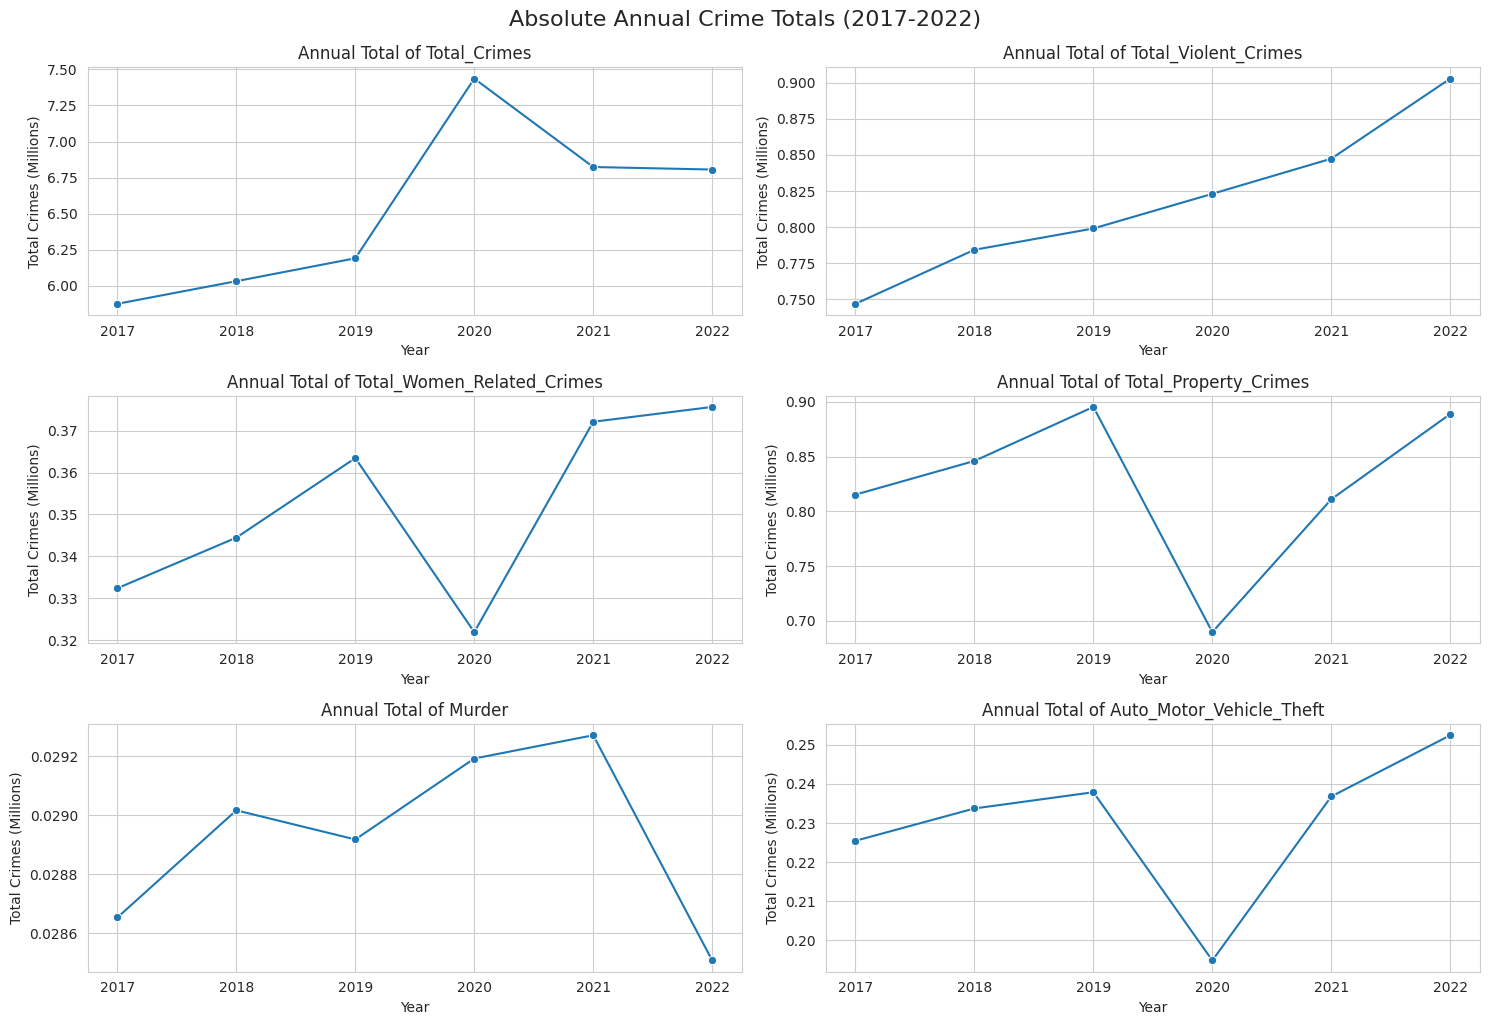

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") #style for the plots

# List of crime categories to visualize
crime_categories_to_plot = [
    'Total_Crimes',
    'Total_Violent_Crimes',
    'Total_Women_Related_Crimes',
    'Total_Property_Crimes',
    'Murder',
    'Auto_Motor_Vehicle_Theft'
]

# Plotting absolute annual crime totals
plt.figure(figsize=(15, 10))
for i, col in enumerate(crime_categories_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(data=annual_crime_totals, x='Year', y=annual_crime_totals[col] / 1_000_000, marker='o')
    plt.title(f'Annual Total of {col}')
    plt.xlabel('Year')
    plt.ylabel('Total Crimes (Millions)')
    plt.xticks(annual_crime_totals['Year'].unique())
plt.tight_layout()
plt.suptitle('Absolute Annual Crime Totals (2017-2022)', y=1.02, fontsize=16)
plt.show()

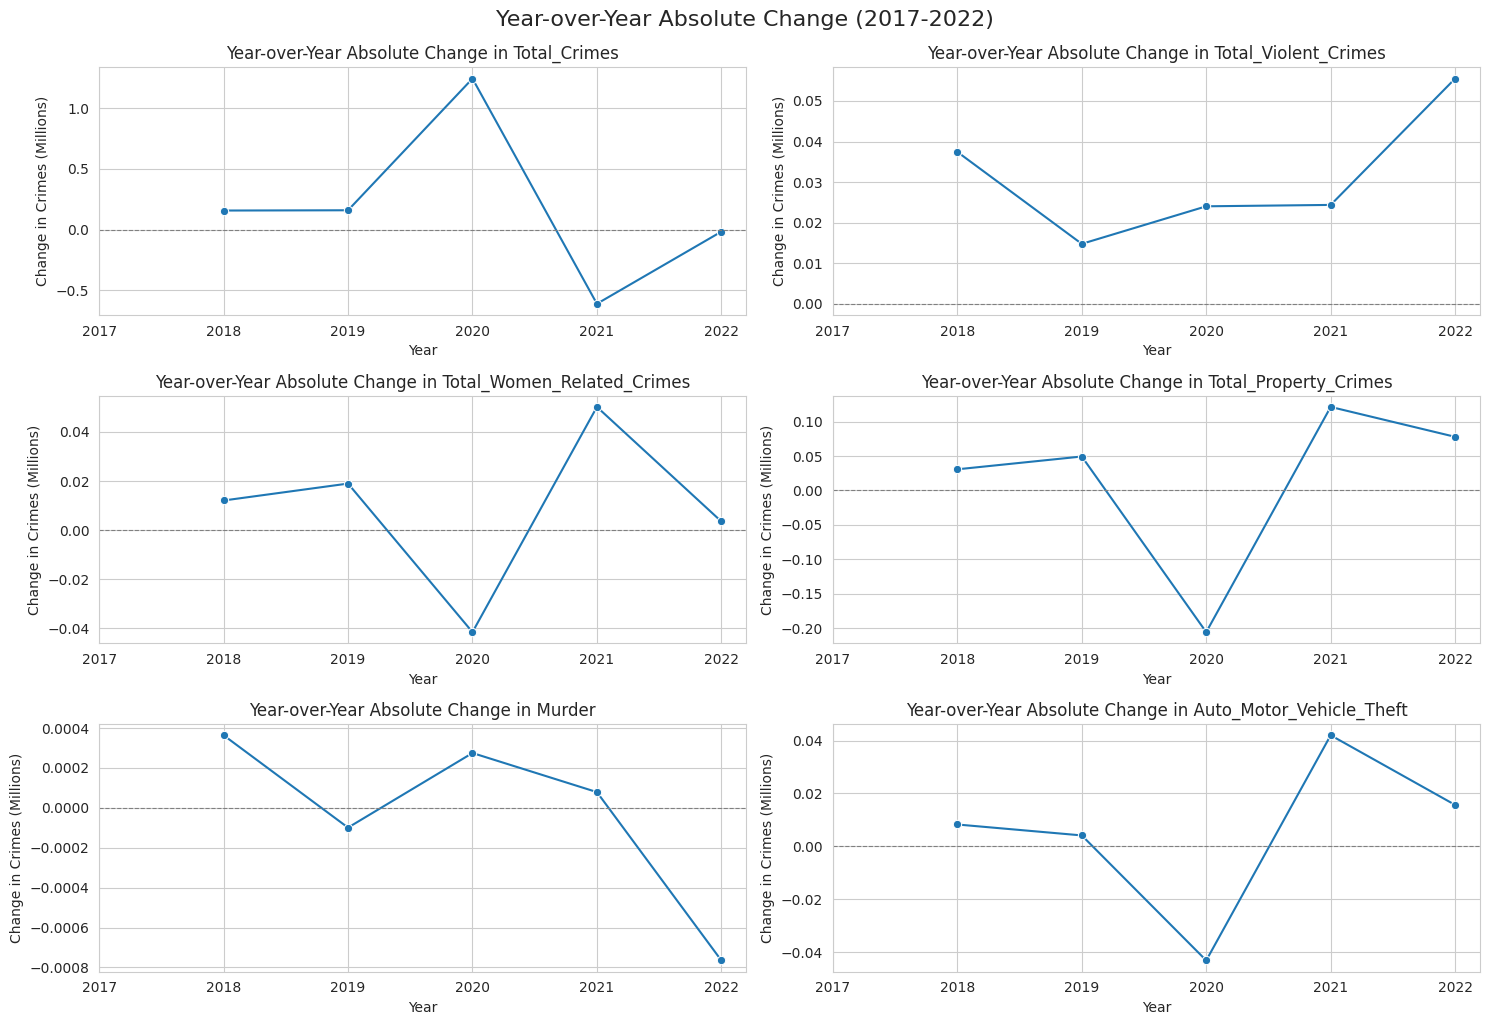

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting year-over-year absolute change
plt.figure(figsize=(15, 10))
for i, col in enumerate(crime_categories_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(data=annual_crime_trends, x='Year', y=annual_crime_trends[col] / 1_000_000, marker='o')
    plt.title(f'Year-over-Year Absolute Change in {col}')
    plt.xlabel('Year')
    plt.ylabel('Change in Crimes (Millions)')
    plt.xticks(annual_crime_trends['Year'].unique())
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.suptitle('Year-over-Year Absolute Change (2017-2022)', y=1.02, fontsize=16)
plt.show()

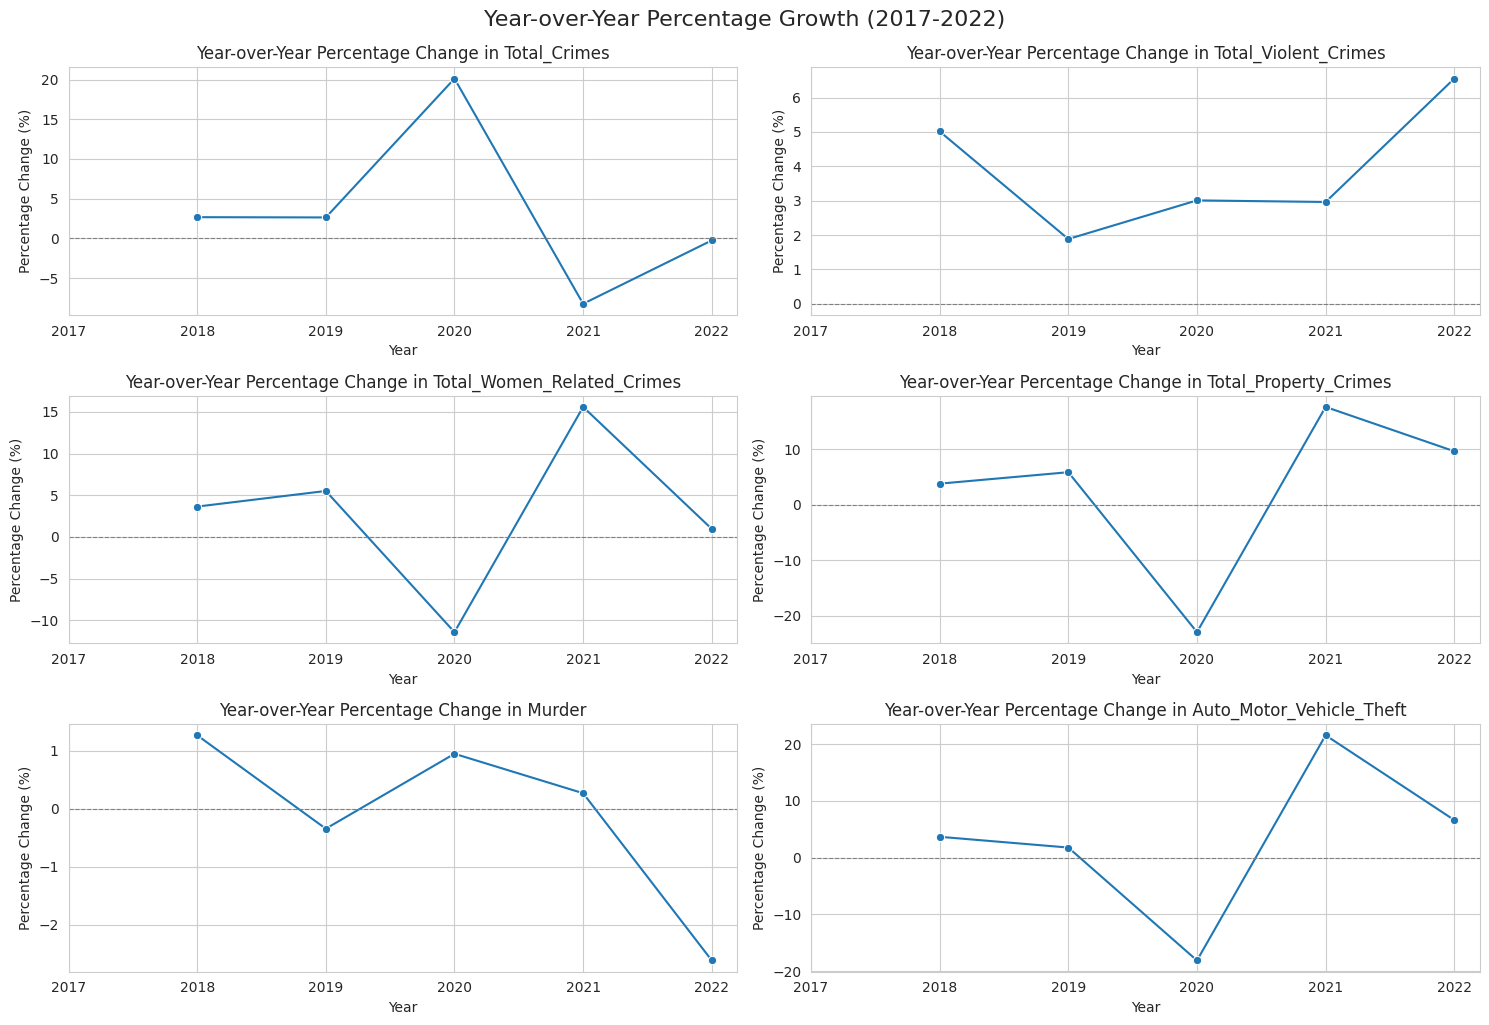

In [ ]:
# Plotting year-over-year percentage growth
plt.figure(figsize=(15, 10))
for i, col in enumerate(crime_categories_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(data=annual_crime_percentage_growth, x='Year', y=col, marker='o')
    plt.title(f'Year-over-Year Percentage Change in {col}')
    plt.xlabel('Year')
    plt.ylabel('Percentage Change (%)')
    plt.xticks(annual_crime_percentage_growth['Year'].unique())
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.suptitle('Year-over-Year Percentage Growth (2017-2022)', y=1.02, fontsize=16)
plt.show()

## Problem Statement 2

Identify geographical crime hotspots at the district and state level; compare crime rates across states and rank the highest-rate districts.

**Reasoning**:
To identify geographical crime hotspots, We need to aggregate the `Total_Crimes` for each district and state. This will be done by grouping the `df_reduced` DataFrame by `State_Name` and `District_Name` for district-level totals, and by `State_Name` for state-level totals.

## Types of Crimes in Top District Hotspots

In [ ]:
# Calculate total crimes per district
district_crime_totals = df_reduced.groupby(['State_Name', 'District_Name'])['Total_Crimes'].sum().reset_index()

# Calculate total crimes per state
state_crime_totals = df_reduced.groupby('State_Name')['Total_Crimes'].sum().reset_index()

# Rank districts by total crimes (top 10)
district_crime_hotspots = district_crime_totals.sort_values(by='Total_Crimes', ascending=False).head(10)

# Rank states by total crimes (top 10)
state_crime_hotspots = state_crime_totals.sort_values(by='Total_Crimes', ascending=False).head(10)

print("Total crimes per district (first 5 rows):")
display(district_crime_totals.head())

print("\nTotal crimes per state (first 5 rows):")
display(state_crime_totals.head())

print("\nTop 10 District Crime Hotspots:")
display(district_crime_hotspots)

print("\nTop 10 State Crime Hotspots:")
display(state_crime_hotspots)

Total crimes per district (first 5 rows):


,State_Name,District_Name,Total_Crimes
0,Andaman And Nicobar Islands,Nicobars,245.0
1,Andaman And Nicobar Islands,North And Middle Andaman,1410.0
2,Andaman And Nicobar Islands,South Andamans,4742.0
3,Andhra Pradesh,Alluri Sitharama Raju,1778.0
4,Andhra Pradesh,Anakapalli,8602.0



Total crimes per state (first 5 rows):


,State_Name,Total_Crimes
0,Andaman And Nicobar Islands,6397.0
1,Andhra Pradesh,1715168.0
2,Arunachal Pradesh,27985.0
3,Assam,1167238.0
4,Bihar,2328958.0



Top 10 District Crime Hotspots:


,State_Name,District_Name,Total_Crimes
166,Delhi,North West,849149.0
402,Maharashtra,Mumbai,834263.0
410,Maharashtra,Pune,445838.0
605,Telangana,Hyderabad,438484.0
174,Gujarat,Ahmadabad,420777.0
288,Karnataka,Bengaluru Urban,417839.0
170,Delhi,South West,395733.0
316,Kerala,Ernakulam,369672.0
542,Rajasthan,Jaipur,347150.0
326,Kerala,Thiruvananthapuram,344780.0



Top 10 State Crime Hotspots:


,State_Name,Total_Crimes
19,Maharashtra,4152641.0
33,Uttar Pradesh,3989787.0
7,Delhi,3227673.0
18,Madhya Pradesh,3192565.0
29,Tamil Nadu,2907142.0
4,Bihar,2328958.0
9,Gujarat,2256555.0
27,Rajasthan,2229418.0
15,Kerala,2188466.0
1,Andhra Pradesh,1715168.0


In [ ]:
# Get the list of top district names and their states
top_district_data = district_crime_hotspots[['State_Name', 'District_Name']]

# Filter df_reduced to include only data from these top districts
# Using a merge to efficiently filter and ensure correct state-district pairing
df_hotspots_trends = pd.merge(
    df_reduced,
    top_district_data,
    on=['State_Name', 'District_Name'],
    how='inner'
)

# Exclude identifier columns from the crime type analysis
identifier_cols_for_analysis = ['Row_ID', 'Year', 'State_Name', 'State_Code', 'District_Name', 'District_Code', 'Police_Station_Circle']
crime_type_cols = [col for col in df_hotspots_trends.columns if col not in identifier_cols_for_analysis]

print("Data for top district hotspots (first 5 rows):")
display(df_hotspots_trends.head())

Data for top district hotspots (first 5 rows):


,Row_ID,Year,State_Name,State_Code,District_Name,District_Code,Police_Station_Circle,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,160,2017,Gujarat,24,Ahmadabad,438,Ahmedabad City,1956.0,1230.0,4324.0,6126.0,4592.0,36524.0,216.0,1370.0,4294.0,264.0,150.0,74.0,6126.0,2915.0,2031.0,90.0,2.0,55.0,1.0,59.0,64.0,40.0,1.0,2017.0,1229.0,253.0,16.0,422.0
1,161,2017,Gujarat,24,Ahmadabad,438,Ahmedabad Rural,538.0,99.0,198.0,994.0,1837.0,7491.0,110.0,173.0,195.0,7.0,22.0,15.0,994.0,406.0,1682.0,20.0,1.0,18.0,NaN,NaN,15.0,8.0,NaN,73.0,39.0,17.0,6.0,21.0
2,290,2017,Karnataka,29,Bengaluru Urban,525,Bengaluru City,5387.0,2758.0,15107.0,6319.0,8700.0,85427.0,1015.0,3523.0,14748.0,1055.0,359.0,131.0,6298.0,4212.0,5238.0,235.0,48.0,134.0,2.0,645.0,130.0,92.0,5.0,6155.0,4649.0,948.0,91.0,2539.0
3,291,2017,Karnataka,29,Bengaluru Urban,525,Bengaluru District,1346.0,381.0,1423.0,189.0,2130.0,10979.0,179.0,525.0,1393.0,143.0,27.0,20.0,184.0,455.0,2308.0,63.0,19.0,6.0,NaN,111.0,20.0,1.0,NaN,552.0,290.0,81.0,11.0,336.0
4,317,2017,Karnataka,29,Bengaluru Urban,525,K.Railways,90.0,19.0,1621.0,2.0,17.0,3508.0,25.0,41.0,1617.0,14.0,0.0,0.0,2.0,11.0,15.0,17.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,28.0,1489.0,90.0,1.0,7.0


Now, for each of the top districts, we will sum the crime counts for each crime category and identify the most prevalent types.

In [ ]:
# Get the list of top 10 district names from district_crime_hotspots
top_10_districts = district_crime_hotspots['District_Name'].tolist()

# Filter df_reduced to include only the top 10 districts
df_top_districts = df_reduced[df_reduced['District_Name'].isin(top_10_districts)]

# Aggregate Total_Crimes by Year, State_Name, and District_Name for the top districts
district_annual_trends = df_top_districts.groupby(['Year', 'State_Name', 'District_Name'])['Total_Crimes'].sum().reset_index()

print("Annual crime trends for top 10 districts (first 5 rows):")
display(district_annual_trends.head())

Annual crime trends for top 10 districts (first 5 rows):


,Year,State_Name,District_Name,Total_Crimes
0,2017,Delhi,North West,139793.0
1,2017,Delhi,South West,47234.0
2,2017,Gujarat,Ahmadabad,45262.0
3,2017,Karnataka,Bengaluru Urban,99914.0
4,2017,Kerala,Ernakulam,84216.0


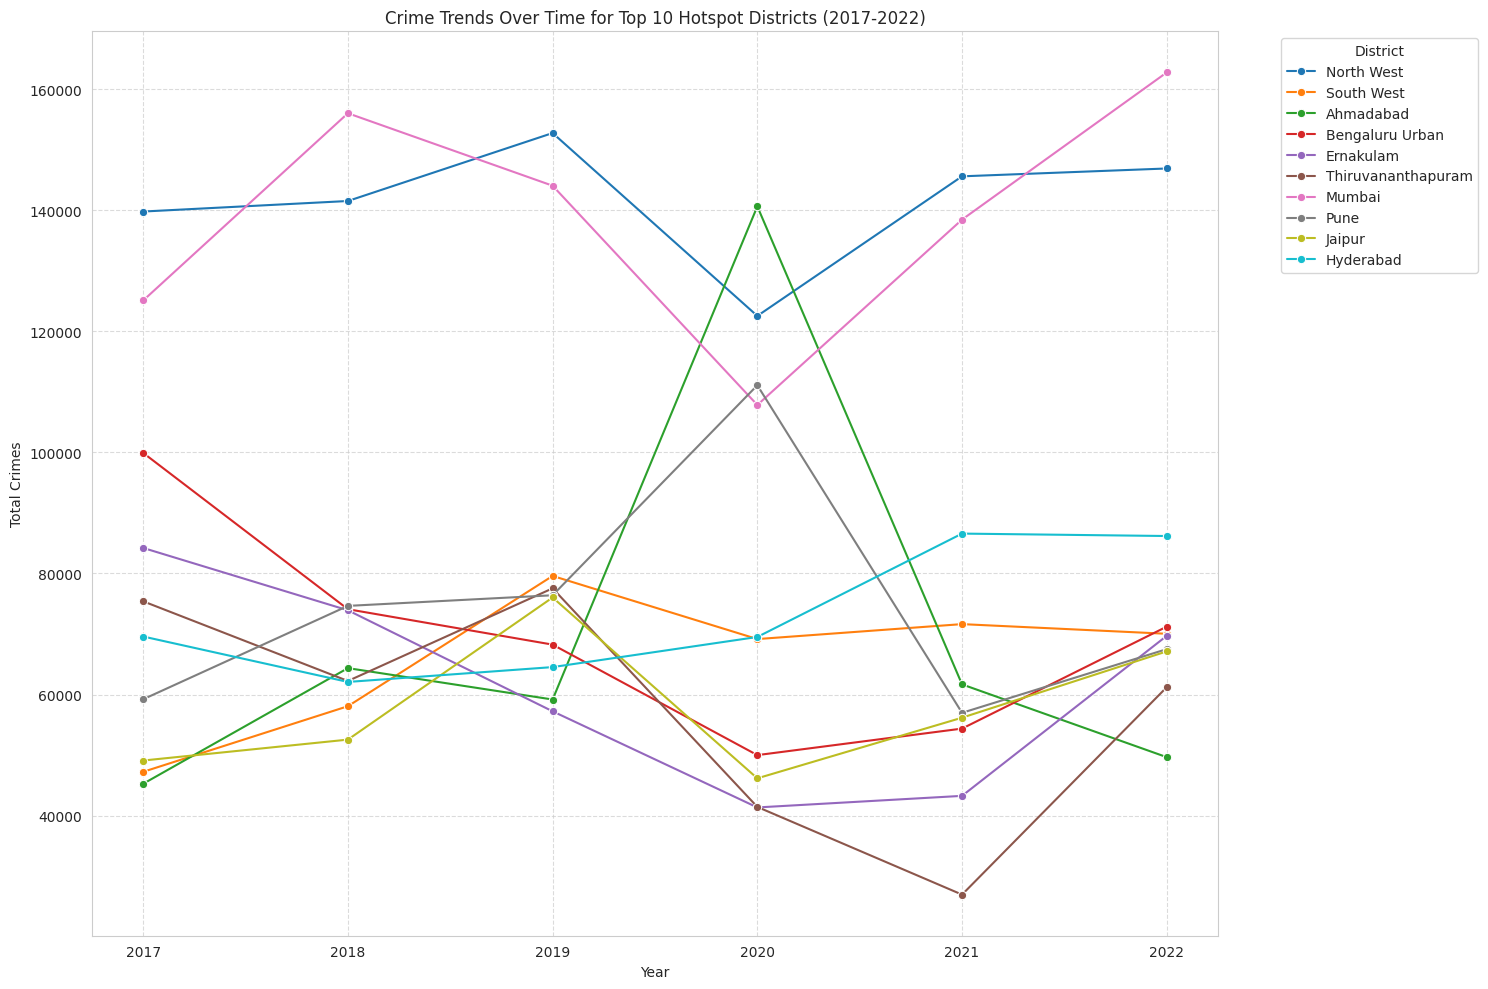

In [ ]:
plt.figure(figsize=(15, 10))
sns.lineplot(data=district_annual_trends, x='Year', y='Total_Crimes', hue='District_Name', marker='o')
plt.title('Crime Trends Over Time for Top 10 Hotspot Districts (2017-2022)')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.xticks(district_annual_trends['Year'].unique())
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Rank districts by total crimes (top 10)
district_crime_hotspots = district_crime_totals.sort_values(by='Total_Crimes', ascending=False).head(10)

# Rank states by total crimes (top 10)
state_crime_hotspots = state_crime_totals.sort_values(by='Total_Crimes', ascending=False).head(10)

print("Top 10 District Crime Hotspots:")
display(district_crime_hotspots)

print("\nTop 10 State Crime Hotspots:")
display(state_crime_hotspots)

Top 10 District Crime Hotspots:


,State_Name,District_Name,Total_Crimes
166,Delhi,North West,849149.0
402,Maharashtra,Mumbai,834263.0
410,Maharashtra,Pune,445838.0
605,Telangana,Hyderabad,438484.0
174,Gujarat,Ahmadabad,420777.0
288,Karnataka,Bengaluru Urban,417839.0
170,Delhi,South West,395733.0
316,Kerala,Ernakulam,369672.0
542,Rajasthan,Jaipur,347150.0
326,Kerala,Thiruvananthapuram,344780.0



Top 10 State Crime Hotspots:


,State_Name,Total_Crimes
19,Maharashtra,4152641.0
33,Uttar Pradesh,3989787.0
7,Delhi,3227673.0
18,Madhya Pradesh,3192565.0
29,Tamil Nadu,2907142.0
4,Bihar,2328958.0
9,Gujarat,2256555.0
27,Rajasthan,2229418.0
15,Kerala,2188466.0
1,Andhra Pradesh,1715168.0


In [ ]:
# Calculate total crimes per district
district_crime_totals = df_reduced.groupby(['State_Name', 'District_Name'])['Total_Crimes'].sum().reset_index()

# Calculate total crimes per state
state_crime_totals = df_reduced.groupby('State_Name')['Total_Crimes'].sum().reset_index()

print("Total crimes per district (first 5 rows):")
display(district_crime_totals.head())

print("\nTotal crimes per state (first 5 rows):")
display(state_crime_totals.head())

Total crimes per district (first 5 rows):


,State_Name,District_Name,Total_Crimes
0,Andaman And Nicobar Islands,Nicobars,245.0
1,Andaman And Nicobar Islands,North And Middle Andaman,1410.0
2,Andaman And Nicobar Islands,South Andamans,4742.0
3,Andhra Pradesh,Alluri Sitharama Raju,1778.0
4,Andhra Pradesh,Anakapalli,8602.0



Total crimes per state (first 5 rows):


,State_Name,Total_Crimes
0,Andaman And Nicobar Islands,6397.0
1,Andhra Pradesh,1715168.0
2,Arunachal Pradesh,27985.0
3,Assam,1167238.0
4,Bihar,2328958.0


In [ ]:
def get_top_crime_types(df_filtered, group_cols, crime_cols, top_n=5):
    grouped_crimes = df_filtered.groupby(group_cols)[crime_cols].sum().reset_index()

    for index, row in grouped_crimes.iterrows():
        hotspot_name = ' - '.join([str(row[col]) for col in group_cols])
        crime_counts = row[crime_cols].sort_values(ascending=False)

        # Filter out crime types with 0 or NaN values and 'Total_Crimes' category itself.
        relevant_crime_counts = crime_counts[(crime_counts > 0) & (crime_counts.index != 'Total_Crimes')]

        print(f"\nTop {top_n} crime types in {hotspot_name}:")
        display(relevant_crime_counts.head(top_n).to_frame(name='Total_Count'))

# Analyze top crime types for district hotspots
get_top_crime_types(df_hotspots_trends, ['State_Name', 'District_Name'], crime_type_cols, top_n=5)


Top 5 crime types in Delhi - North West:


,Total_Count
Total_Property_Crimes,331287.0
Combined_Theft_Burglary,331049.0
Other_Thefts,249837.0
Auto_Motor_Vehicle_Theft,69339.0
Total_Public_Order_Riots,46553.0



Top 5 crime types in Delhi - South West:


,Total_Count
Total_Property_Crimes,146679.0
Combined_Theft_Burglary,146565.0
Other_Thefts,117264.0
Auto_Motor_Vehicle_Theft,23811.0
Total_Public_Order_Riots,21878.0



Top 5 crime types in Gujarat - Ahmadabad:


...

,Total_Count
Total_Property_Crimes,74587.0
Combined_Theft_Burglary,73172.0
Total_Public_Order_Riots,53525.0
Combined_Rioting_Public_Order,53412.0
Total_Economic_Crimes,35327.0



Top 5 crime types in Rajasthan - Jaipur:


,Total_Count
Total_Property_Crimes,64679.0
Combined_Theft_Burglary,64499.0
Total_Economic_Crimes,48127.0
Auto_Motor_Vehicle_Theft,40087.0
Combined_Fraud_Cheating,32636.0



Top 5 crime types in Telangana - Hyderabad:


,Total_Count
Total_Economic_Crimes,79314.0
Total_Property_Crimes,59521.0
Combined_Theft_Burglary,55890.0
Combined_Fraud_Cheating,46403.0
Combined_Accidents_Negligence,38130.0


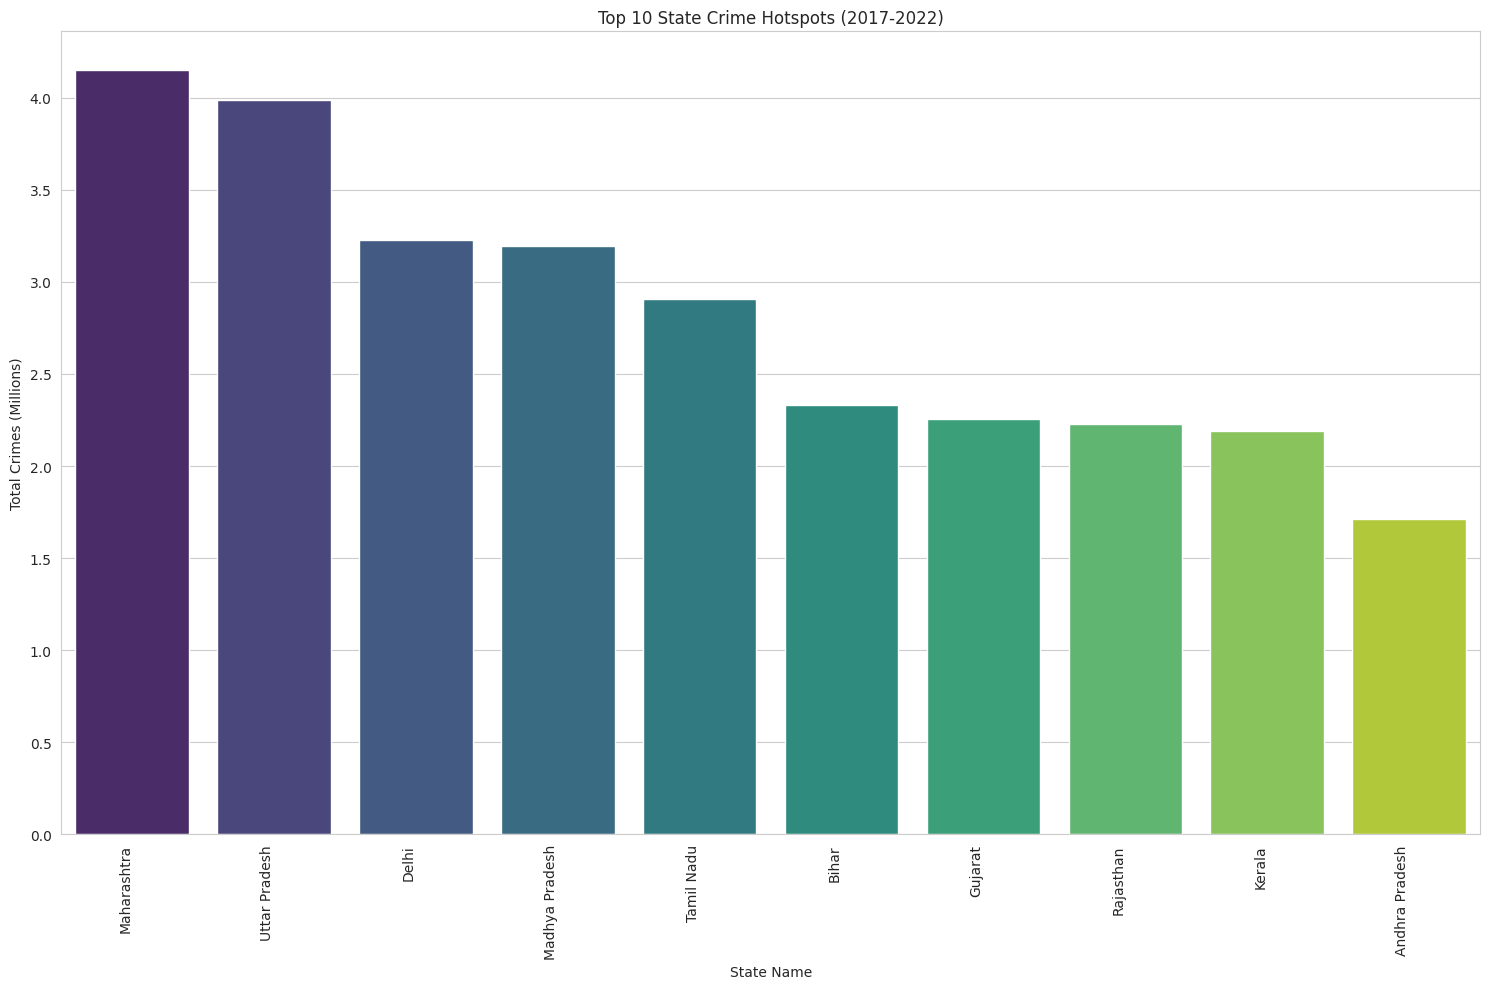

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(15, 10))
sns.barplot(x='State_Name', y=state_crime_hotspots['Total_Crimes'] / 1_000_000, data=state_crime_hotspots.sort_values(by='Total_Crimes', ascending=False), palette='viridis', hue='State_Name', legend=False)
plt.title('Top 10 State Crime Hotspots (2017-2022)')
plt.xlabel('State Name')
plt.ylabel('Total Crimes (Millions)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

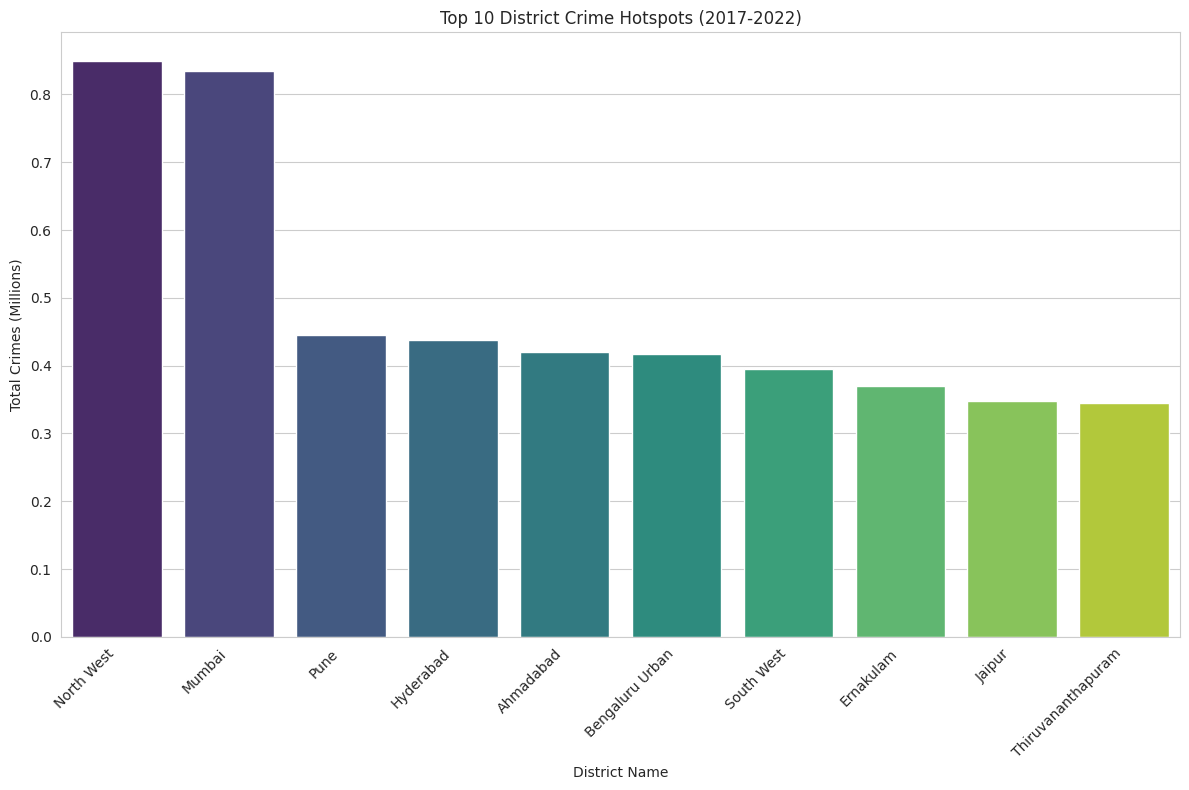

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 8))
sns.barplot(x='District_Name', y=district_crime_hotspots['Total_Crimes'] / 1_000_000, data=district_crime_hotspots, palette='viridis', hue='District_Name', legend=False)
plt.title('Top 10 District Crime Hotspots (2017-2022)')
plt.xlabel('District Name')
plt.ylabel('Total Crimes (Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To rank the crime hotspots, I will sort the `district_crime_totals` and `state_crime_totals` DataFrames in descending order of `Total_Crimes`. This will allow us to easily identify and display the top districts and states with the highest crime occurrences.

**Reasoning**:
To rank the crime hotspots, I will sort the `district_crime_totals` and `state_crime_totals` DataFrames in descending order of `Total_Crimes`. This will allow us to easily identify and display the top districts and states with the highest crime occurrences.

## Correlation Between All Crime Categories and Important Crime Categories

To address the user's request, we will generate a new correlation matrix that shows all crime-related columns on one axis and the previously defined 'important_crime_cols' on the other. This provides a focused view of how individual crime types relate to the broader, high-level categories.

Correlation Matrix: All Crime Types vs. Important Crime Types:


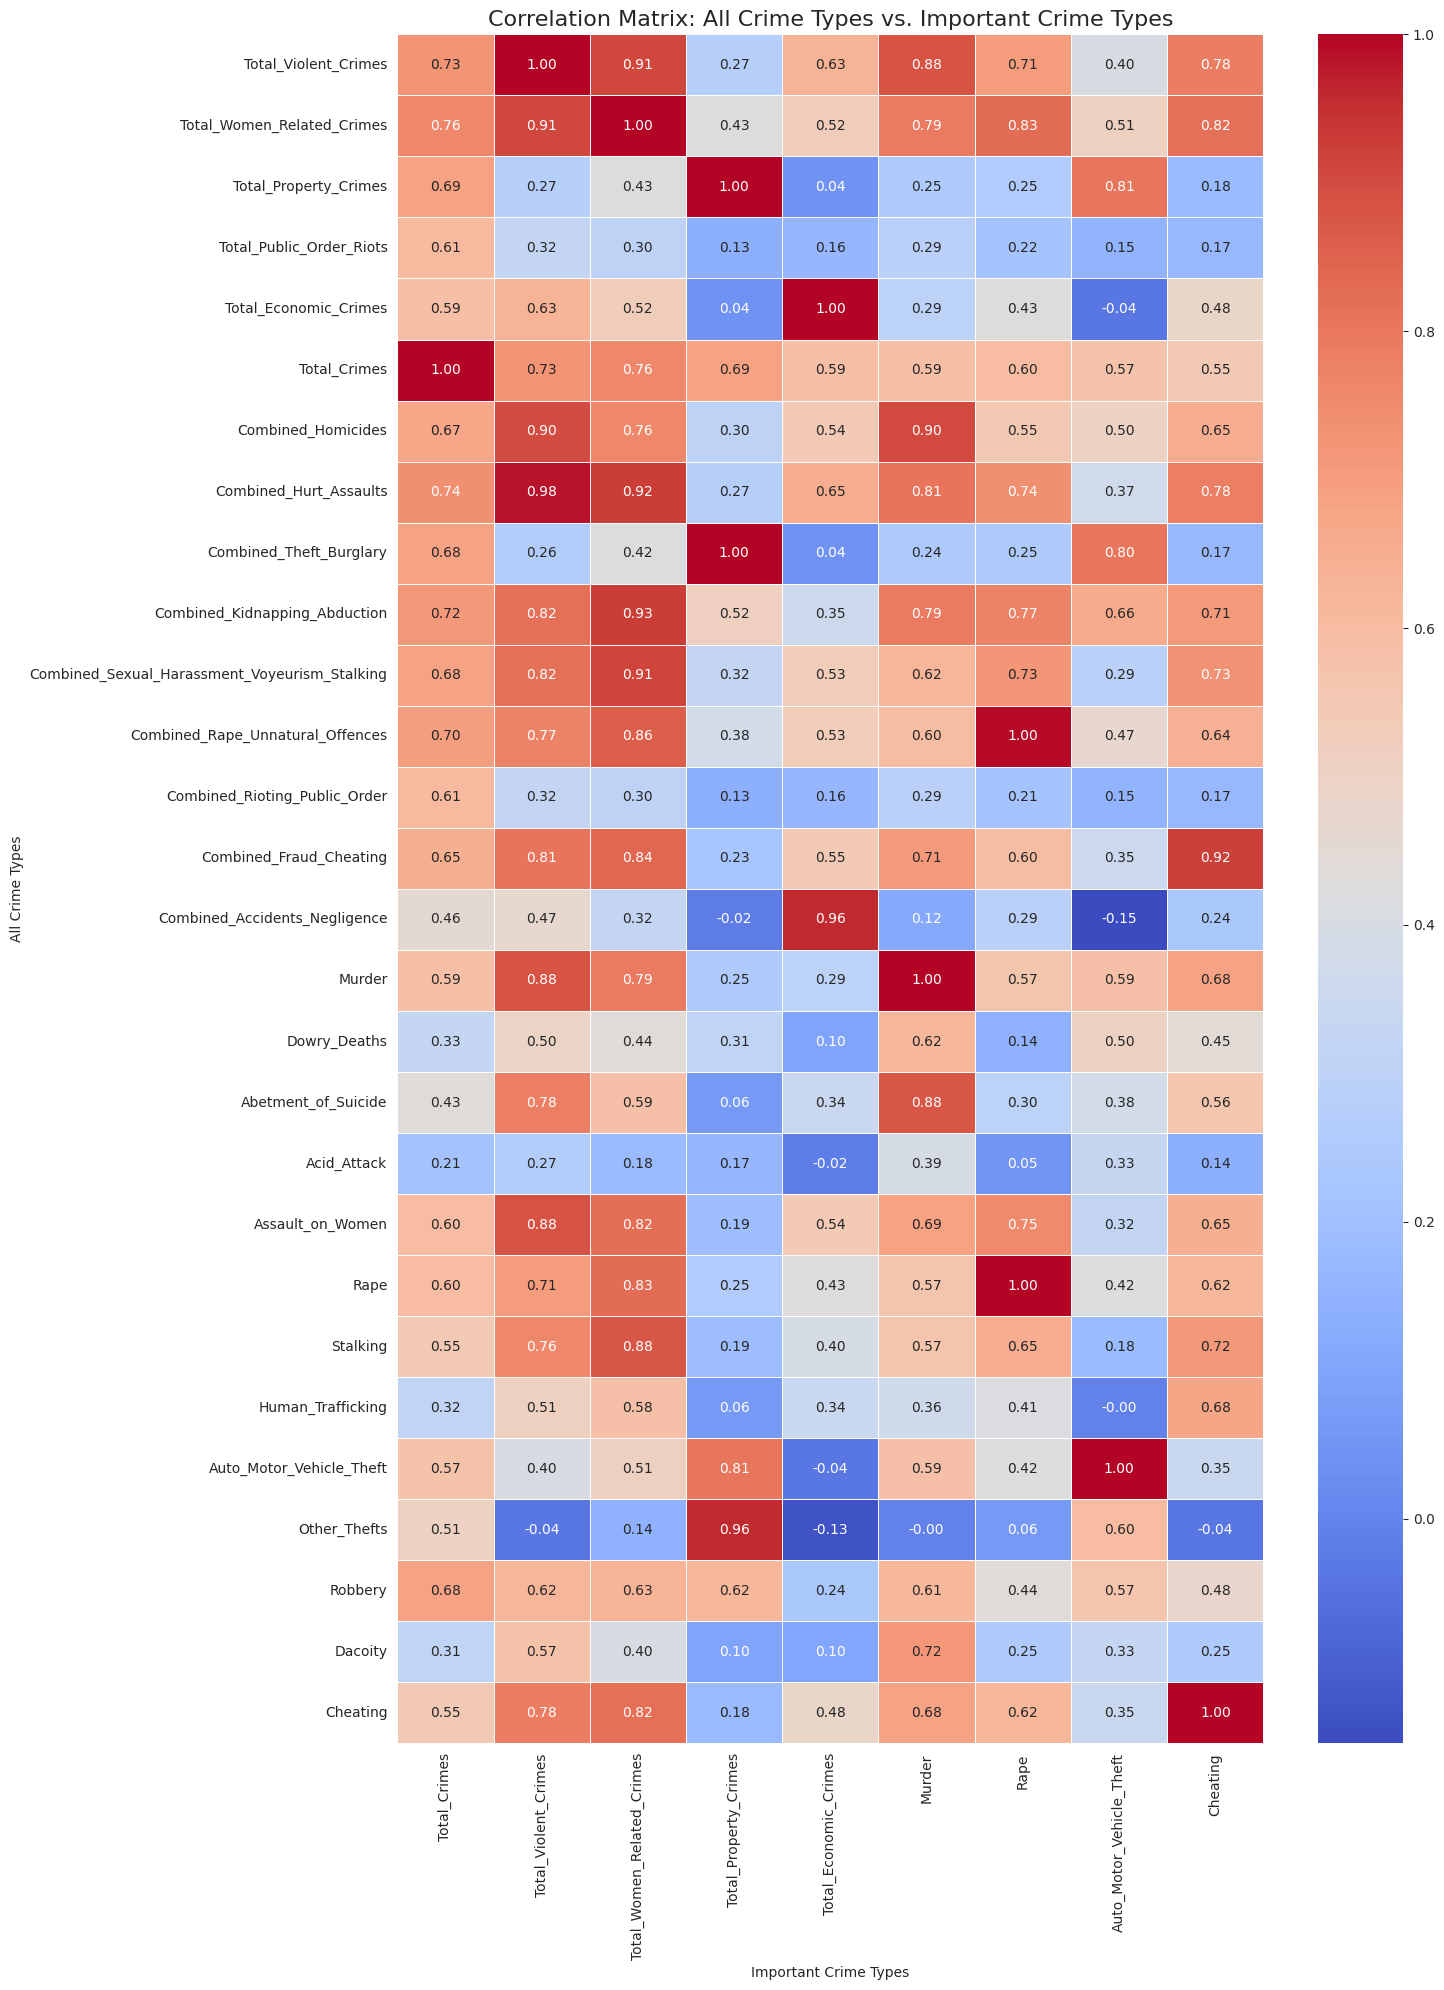

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'crime_cols_for_correlation' and 'important_crime_cols' are defined
# (these were defined in the previous executed cell dfbc693f)
identifier_cols_for_correlation = ['Row_ID', 'Year', 'State_Name', 'State_Code', 'District_Name', 'District_Code', 'Police_Station_Circle']
crime_cols_for_correlation = [col for col in df_hotspots_trends.columns if col not in identifier_cols_for_correlation]

important_crime_cols = [
    'Total_Crimes',
    'Total_Violent_Crimes',
    'Total_Women_Related_Crimes',
    'Total_Property_Crimes',
    'Total_Economic_Crimes',
    'Murder',
    'Rape',
    'Auto_Motor_Vehicle_Theft',
    'Cheating'
]

# Calculate the correlation matrix for all crime-related columns
correlation_matrix_all = df_hotspots_trends[crime_cols_for_correlation].corr()

# Create the new specific correlation matrix: all crime types vs important crime types
# Rows will be all crime categories, columns will be important crime categories
correlation_all_vs_important = correlation_matrix_all.loc[crime_cols_for_correlation, important_crime_cols]

print("Correlation Matrix: All Crime Types vs. Important Crime Types:")
plt.figure(figsize=(15, 20)) # Adjust figure size for better readability
sns.heatmap(correlation_all_vs_important, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: All Crime Types vs. Important Crime Types', fontsize=16)
plt.xlabel('Important Crime Types')
plt.ylabel('All Crime Types')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


## Problem Statement 3
## Classify Districts as Urban or Rural

To analyze crime prevalence by urban and rural settings, we need to classify each district. Since the dataset does not contain an explicit `urban_rural` column, we will create one based on common knowledge of major urban centers in India. Districts matching these names will be classified as 'Urban', and all others as 'Rural'.

In [ ]:
urban_district_names = [
    'Mumbai', 'Bengaluru Urban', 'Chennai', 'Kolkata', 'Delhi', 'Hyderabad',
    'Ahmadabad', 'Pune', 'Jaipur', 'Lucknow', 'Kanpur', 'Nagpur', 'Indore',
    'Thane', 'Bhopal', 'Visakhapatnam', 'Pimpri-Chinchwad', 'Patna', 'Vadodara',
    'Ghaziabad', 'Agra', 'Faridabad', 'Meerut', 'Nashik', 'Rajkot', 'Varanasi',
    'Srinagar', 'Ernakulam', 'North West', 'South West'
] # This list can be expanded or refined with more comprehensive data

# Create a new column for urban/rural classification
df_reduced['Urban_Rural_Classification'] = df_reduced['District_Name'].apply(
    lambda x: 'Urban' if x in urban_district_names else 'Rural'
)

print("District classification added to df_reduced:")
display(df_reduced[['District_Name', 'Urban_Rural_Classification']])

District classification added to df_reduced:


,District_Name,Urban_Rural_Classification
0,Ananthapuramu,Rural
1,Chittoor,Rural
2,Y.S.R.,Rural
3,East Godavari,Rural
4,Ananthapuramu,Rural
...,...,...
5317,Srinagar,Urban
5318,Srinagar,Urban
5319,Jammu,Rural
5320,Srinagar,Urban


## Aggregate Crime Data by Urban/Rural Classification

Now, we will aggregate the crime totals for each crime category based on the new `Urban_Rural_Classification`. This will give us a sum of all crime types in urban versus rural districts.

In [ ]:
# Exclude identifier columns from the sum, keeping only crime-related columns
identifier_cols_for_grouping = ['Row_ID', 'Year', 'State_Name', 'State_Code', 'District_Name', 'District_Code', 'Police_Station_Circle', 'Urban_Rural_Classification']
crime_cols_for_urban_rural = [col for col in df_reduced.columns if col not in identifier_cols_for_grouping]

urban_rural_crime_totals = df_reduced.groupby('Urban_Rural_Classification')[crime_cols_for_urban_rural].sum().reset_index()

print("Aggregated crime totals by Urban/Rural Classification:")
display(urban_rural_crime_totals)

Aggregated crime totals by Urban/Rural Classification:


,Urban_Rural_Classification,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,Rural,4309217.0,1788119.0,3462296.0,1521477.0,3439563.0,31290765.0,598636.0,2927916.0,3291781.0,502180.0,171060.0,191119.0,1512556.0,1371834.0,2798762.0,154471.0,38021.0,44507.0,1104.0,249534.0,164422.0,39505.0,5107.0,963115.0,1417082.0,125640.0,15309.0,452605.0
1,Urban,594355.0,321849.0,1483608.0,593125.0,784109.0,7870155.0,66295.0,427032.0,1460320.0,105342.0,45935.0,27463.0,591741.0,324636.0,552252.0,19089.0,3895.0,7833.0,168.0,35083.0,24718.0,14856.0,2032.0,418007.0,824516.0,48616.0,2875.0,153373.0


## Normalize Crime Data for Comparison

To effectively compare the prevalence of crime types between urban and rural areas, it's important to normalize the data. We will convert the absolute crime counts into proportions (percentage of total crimes within each classification) to account for potential differences in the number of districts or overall crime volumes between urban and rural categories.

In [ ]:
# Calculate the percentage of each crime type within Urban and Rural categories
urban_rural_crime_proportions = urban_rural_crime_totals.set_index('Urban_Rural_Classification').apply(lambda x: x / x['Total_Crimes'], axis=1)
urban_rural_crime_proportions = urban_rural_crime_proportions.reset_index()

print("Proportion of each crime type within Urban/Rural Classification:")
display(urban_rural_crime_proportions.head())

Proportion of each crime type within Urban/Rural Classification:


,Urban_Rural_Classification,Total_Violent_Crimes,Total_Women_Related_Crimes,Total_Property_Crimes,Total_Public_Order_Riots,Total_Economic_Crimes,Total_Crimes,Combined_Homicides,Combined_Hurt_Assaults,Combined_Theft_Burglary,Combined_Kidnapping_Abduction,Combined_Sexual_Harassment_Voyeurism_Stalking,Combined_Rape_Unnatural_Offences,Combined_Rioting_Public_Order,Combined_Fraud_Cheating,Combined_Accidents_Negligence,Murder,Dowry_Deaths,Abetment_of_Suicide,Acid_Attack,Assault_on_Women,Rape,Stalking,Human_Trafficking,Auto_Motor_Vehicle_Theft,Other_Thefts,Robbery,Dacoity,Cheating
0,Rural,0.137715,0.057145,0.110649,0.048624,0.109923,1.0,0.019131,0.093571,0.105200,0.016049,0.005467,0.006108,0.048339,0.043841,0.089444,0.004937,0.001215,0.001422,0.000035,0.007975,0.005255,0.001263,0.000163,0.030780,0.045288,0.004015,0.000489,0.014464
1,Urban,0.075520,0.040895,0.188511,0.075364,0.099631,1.0,0.008424,0.054260,0.185552,0.013385,0.005837,0.003490,0.075188,0.041249,0.070170,0.002425,0.000495,0.000995,0.000021,0.004458,0.003141,0.001888,0.000258,0.053113,0.104765,0.006177,0.000365,0.019488


## Visualize Crime Type Prevalence in Urban vs. Rural Areas

Finally, we will visualize the comparison of crime type prevalence. We'll select a few key crime categories to plot and show their proportions in urban versus rural settings.

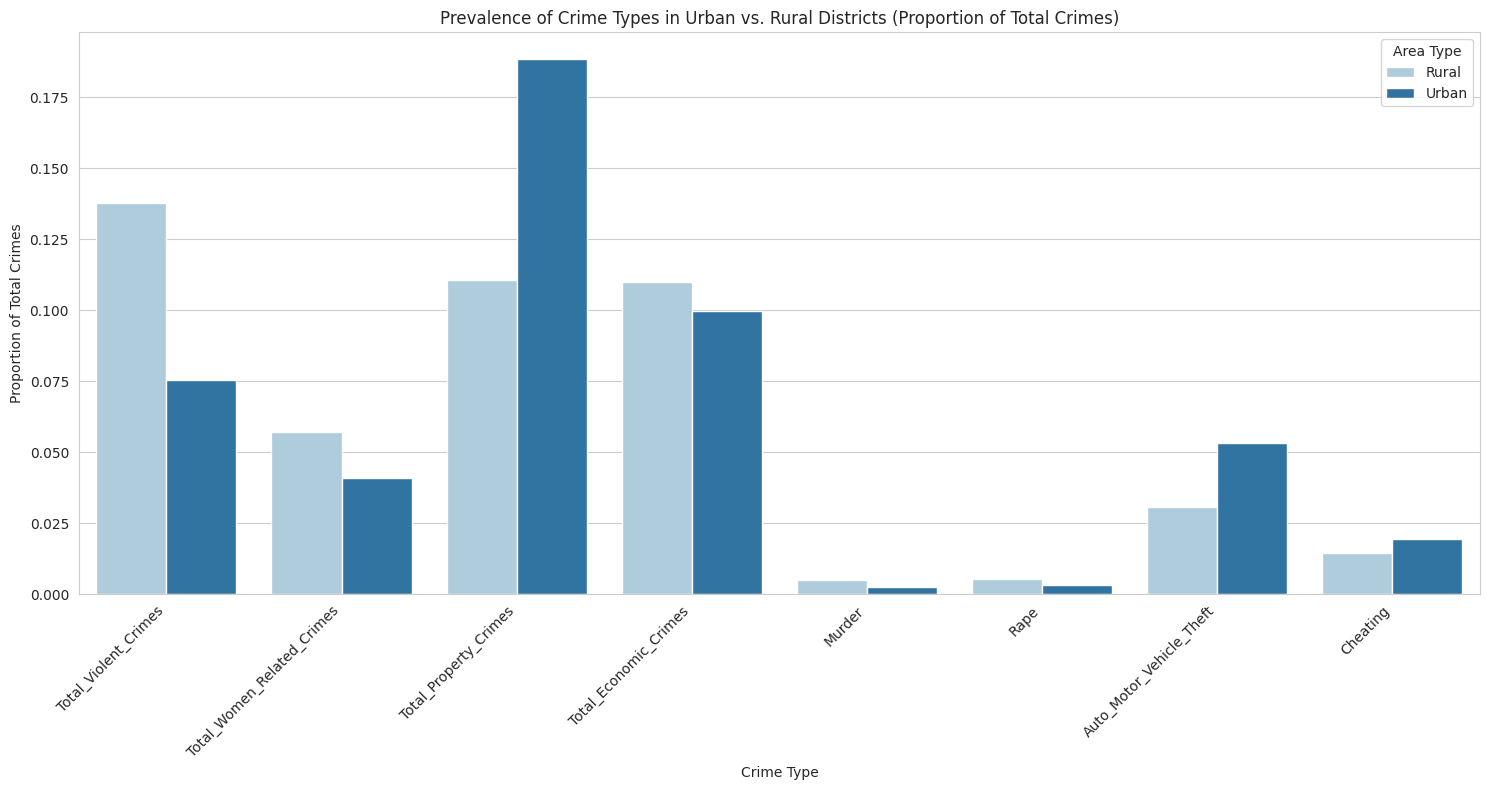


Difference in crime proportions (Urban - Rural):


,Urban_Minus_Rural_Proportion
Combined_Theft_Burglary,0.080352
Total_Property_Crimes,0.077862
Other_Thefts,0.059477
Combined_Rioting_Public_Order,0.026849
Total_Public_Order_Riots,0.026740
Auto_Motor_Vehicle_Theft,0.022333
Cheating,0.005023
Robbery,0.002162
Stalking,0.000625
Combined_Sexual_Harassment_Voyeurism_Stalking,0.000370


,Urban_Minus_Rural_Proportion
Combined_Fraud_Cheating,-0.002593
Combined_Rape_Unnatural_Offences,-0.002618
Combined_Kidnapping_Abduction,-0.002664
Assault_on_Women,-0.003517
Total_Economic_Crimes,-0.010292
Combined_Homicides,-0.010708
Total_Women_Related_Crimes,-0.016250
Combined_Accidents_Negligence,-0.019273
Combined_Hurt_Assaults,-0.039312
Total_Violent_Crimes,-0.062195


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Select a subset of crime categories to visualize
# Exclude 'Total_Crimes' as it's the sum for normalization
crime_categories_for_comparison = [
    'Total_Violent_Crimes',
    'Total_Women_Related_Crimes',
    'Total_Property_Crimes',
    'Total_Economic_Crimes',
    'Murder',
    'Rape',
    'Auto_Motor_Vehicle_Theft',
    'Cheating'
]

# Melt the DataFrame for easier plotting with seaborn
df_plot = urban_rural_crime_proportions[['Urban_Rural_Classification'] + crime_categories_for_comparison].melt(
    id_vars='Urban_Rural_Classification',
    var_name='Crime_Type',
    value_name='Proportion'
)

plt.figure(figsize=(15, 8))
sns.barplot(x='Crime_Type', y='Proportion', hue='Urban_Rural_Classification', data=df_plot, palette='Paired')
plt.title('Prevalence of Crime Types in Urban vs. Rural Districts (Proportion of Total Crimes)')
plt.xlabel('Crime Type')
plt.ylabel('Proportion of Total Crimes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Area Type')
plt.tight_layout()
plt.show()

# You can also analyze the absolute differences in proportions
urban_proportions = urban_rural_crime_proportions[urban_rural_crime_proportions['Urban_Rural_Classification'] == 'Urban'].drop(columns=['Urban_Rural_Classification', 'Total_Crimes']).reset_index(drop=True)
rural_proportions = urban_rural_crime_proportions[urban_rural_crime_proportions['Urban_Rural_Classification'] == 'Rural'].drop(columns=['Urban_Rural_Classification', 'Total_Crimes']).reset_index(drop=True)

# Subtracting now results in a single row DataFrame
difference_df = urban_proportions - rural_proportions

# Transpose to make crime types index and the difference a column
difference_in_proportions = difference_df.transpose()
difference_in_proportions.columns = ['Urban_Minus_Rural_Proportion']

# Now sort by the newly named column
difference_in_proportions = difference_in_proportions.sort_values(by='Urban_Minus_Rural_Proportion', ascending=False)

print("\nDifference in crime proportions (Urban - Rural):")
display(difference_in_proportions.head(10))
display(difference_in_proportions.tail(10))